# GPR Utility Prediction Pipeline

이 노트북은 `all_code.ipynb`의 마크다운 흐름과 `Data_copy.ipynb`의 Sobel/YOLO/Migration 코드를 하나로 묶은 최종 실행용 버전입니다.

전체 흐름은 다음과 같습니다.

1. GPR 원본 이미지 로드  
2. GPR 전처리  
3. TDA / PH-style threshold filtration  
4. PH/Sobel/PH+Sobel YOLO 학습 데이터 생성  
5. YOLO 모델 학습 및 평가  
6. YOLO bbox 또는 GT bbox 기반 Migration  
7. 결과 이미지/JSON/CSV 저장  

> 중요: YOLOv8 기본 모델은 입력 채널이 3채널입니다. 따라서 `PH(2dim)`, `Sobel(2dim)`, `PH+Sobel(4dim)`은 학습용 이미지로 저장할 때 3채널 RGB 형태로 packing합니다.


## 0. Colab 환경 준비

처음 실행하는 경우 아래 셀을 실행하세요. 이미 설치되어 있으면 건너뛰어도 됩니다.


In [ ]:
# Colab에서만 필요합니다.
# !pip install -q ultralytics opencv-python matplotlib pandas pyyaml tqdm

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Google Colab 환경이 아니거나 이미 mount된 상태입니다.")

Mounted at /content/drive


## 1. 기본 설정

아래 경로만 자신의 Drive 구조에 맞게 수정하면 됩니다.

- `SRC_IMG_DIR`: 원본 GPR 이미지 폴더
- `SRC_LABEL_DIR`: YOLO txt 라벨 폴더
- `WORK_DIR`: 변환 데이터, 학습 결과, migration 결과를 저장할 작업 폴더


In [ ]:
!pip install opencv-python

In [ ]:
from pathlib import Path
import os
import json
import math
import random
import shutil
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# =========================
# 사용자가 수정할 경로
# =========================
SRC_IMG_DIR = Path("/content/drive/MyDrive/TDA/Final_Pipeline/img_ori")
SRC_LABEL_DIR = Path("/content/drive/MyDrive/TDA/Final_Pipeline/labels")
WORK_DIR = Path("/content/drive/MyDrive/TDA/Final_Pipeline/")

# Experiments
signal_dir = WORK_DIR/"signal"
sobel_dir = WORK_DIR/"sobel"
PH_dir = WORK_DIR/"PH"
PH_Sobel_dir = WORK_DIR/"PH_sobel"

# 결과 폴더
FEATURE_DATASET_ROOT = WORK_DIR / "yolo_feature_datasets"
RUNS_DIR = WORK_DIR / "runs_gpr"
MIGRATION_RESULT_DIR = WORK_DIR / "migration_results"

for d in [WORK_DIR, FEATURE_DATASET_ROOT, RUNS_DIR, MIGRATION_RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 이미지 확장자
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("SRC_IMG_DIR:", SRC_IMG_DIR)
print("SRC_LABEL_DIR:", SRC_LABEL_DIR)
print("WORK_DIR:", WORK_DIR)

SRC_IMG_DIR: /content/drive/MyDrive/TDA/Final_Pipeline/img_ori
SRC_LABEL_DIR: /content/drive/MyDrive/TDA/Final_Pipeline/labels
WORK_DIR: /content/drive/MyDrive/TDA/Final_Pipeline


## 2. GPR 전처리 함수

`raw_dataprocessing_v2` 계열에서 사용한 전처리 흐름입니다.

구성:
- background removal
- DEWOW
- SEC gain
- tapering
- spectral balancing
- bilateral filter
- CLAHE
- morphological opening


In [ ]:
def gpr_v2_5_topology_optimized_from_array(img_gray, beta=0.003, offset=15):
    """
    GPR 전처리.
    입력: uint8 또는 float grayscale array
    출력: uint8 preprocessed image
    """
    if img_gray is None:
        raise ValueError("img_gray is None")

    img = img_gray.astype(np.float32)

    # 1. Background removal: row-wise mean 제거
    img = img - np.mean(img, axis=1, keepdims=True)

    rows, cols = img.shape
    processed_img = np.zeros_like(img, dtype=np.float32)

    # 2~5. trace-wise processing
    for c in range(cols):
        trace = img[:, c]
        trace = trace - np.mean(trace)  # DEWOW

        t = np.arange(rows)
        gain = (t + offset) * np.exp(beta * t)
        trace_gained = trace * gain

        taper_len = max(1, int(rows * 0.1))
        taper = np.ones(rows, dtype=np.float32)
        taper[-taper_len:] = np.cos(np.linspace(0, np.pi / 2, taper_len))
        trace_gained *= taper

        n_fft = rows * 2
        f_coeff = np.fft.rfft(trace_gained, n=n_fft)
        freqs = np.fft.rfftfreq(n_fft)
        balancing_filter = np.where(freqs > 0.05, 1.2, 0.5)

        restored = np.fft.irfft(f_coeff * balancing_filter, n=n_fft)
        processed_img[:, c] = restored[:rows]

    # 6. Edge-preserving denoise
    denoised = cv2.bilateralFilter(processed_img.astype(np.float32), 9, 75, 75)

    # 7. CLAHE
    norm_img = cv2.normalize(denoised, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(norm_img)

    # 8. Morphological opening
    kernel = np.ones((2, 2), np.uint8)
    final_img = cv2.morphologyEx(clahe_img, cv2.MORPH_OPEN, kernel)

    return final_img


def gpr_v2_5_topology_optimized(image_path, beta=0.003, offset=15):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {image_path}")
    return gpr_v2_5_topology_optimized_from_array(img, beta=beta, offset=offset)


def load_gray_uint8(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {image_path}")
    return img


def normalize01(img, eps=1e-8):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + eps)


def to_uint8(img01):
    img = np.clip(img01, 0, 1)
    return (img * 255).astype(np.uint8)

## 3. TDA / PH-style Dynamic Fixed Filtration

기존 `analyze_gpr_tda_fixed`의 면적 기반 판단을 유지하면서, filtration 중간에 새로 등장한 component도 birth seed로 등록합니다.

핵심:
- Bright: `THRESH_BINARY`, 높은 threshold → 낮은 threshold
- Dark: `THRESH_BINARY_INV`, 낮은 threshold → 높은 threshold
- 새 component birth 등록
- explosion 발생 시 커진 뒤가 아니라 직전 mask 저장


In [ ]:
def run_dynamic_fixed_filtration(
    img,
    start_high=230,
    start_low=10,
    max_area=400,
    min_area=20,
    explosion_ratio=3.0,
    birth_min_area=5,
    birth_max_area=200,
    overlap_threshold=0.2,
    bright_stop=50,
    dark_stop=170,
    threshold_step=2,
):
    """
    전처리된 grayscale image에 대해 bright/dark dynamic filtration 수행.

    return:
        result_img: contour overlay BGR image
        all_seeds: seed dict
        masks: {"bright": bright_mask, "dark": dark_mask, "merged": merged_mask}
        candidates: bbox/area/type 정보 list
    """
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    current_labels = np.zeros(img.shape, dtype=np.int32)

    all_seeds = {}
    global_seed_count = 1

    modes = [
        {
            "name": "Bright",
            "start": start_high,
            "step": -abs(threshold_step),
            "thresh_type": cv2.THRESH_BINARY,
            "stop": bright_stop,
        },
        {
            "name": "Dark",
            "start": start_low,
            "step": abs(threshold_step),
            "thresh_type": cv2.THRESH_BINARY_INV,
            "stop": dark_stop,
        },
    ]

    for mode in modes:
        mode_seeds = {}
        target_range = range(mode["start"], mode["stop"], mode["step"])

        for t in target_range:
            _, current_mask = cv2.threshold(img, t, 255, mode["thresh_type"])
            num_labels, labels_map, stats, centroids = cv2.connectedComponentsWithStats(current_mask)

            # A. 기존 seed 추적
            for s_id, info in list(mode_seeds.items()):
                if info["is_frozen"]:
                    continue

                cy, cx = info["anchor_pt"]
                target_label = labels_map[cy, cx]

                if target_label == 0:
                    continue

                new_area = int(stats[target_label, cv2.CC_STAT_AREA])
                new_component_mask = (labels_map == target_label).astype(np.uint8) * 255

                if new_area < min_area:
                    current_labels[labels_map == target_label] = s_id
                    info["last_area"] = new_area
                    info["last_mask"] = new_component_mask

                elif (new_area > info["last_area"] * explosion_ratio) or (new_area > max_area):
                    info["is_frozen"] = True

                    # explosion 직전 모양 보존
                    if info["last_mask"] is not None:
                        info["final_mask"] = info["last_mask"].copy()
                    else:
                        info["final_mask"] = (current_labels == s_id).astype(np.uint8) * 255

                    info["death_threshold"] = t

                else:
                    current_labels[labels_map == target_label] = s_id
                    info["last_area"] = new_area
                    info["last_mask"] = new_component_mask

            # B. 새 component birth 등록
            for idx in range(1, num_labels):
                area = int(stats[idx, cv2.CC_STAT_AREA])

                if area < birth_min_area or area > birth_max_area:
                    continue

                component_mask = labels_map == idx

                occupied_pixels = current_labels[component_mask] > 0
                overlap_ratio = float(np.sum(occupied_pixels) / max(area, 1))

                if overlap_ratio > overlap_threshold:
                    continue

                cx_float, cy_float = centroids[idx]
                cx = int(round(cx_float))
                cy = int(round(cy_float))
                cy = max(0, min(cy, img.shape[0] - 1))
                cx = max(0, min(cx, img.shape[1] - 1))

                # centroid가 component 내부가 아니면 component 내부 점으로 보정
                if labels_map[cy, cx] != idx:
                    ys, xs = np.where(component_mask)
                    if len(ys) == 0:
                        continue
                    mid = len(ys) // 2
                    cy, cx = int(ys[mid]), int(xs[mid])

                s_id = global_seed_count
                new_mask = component_mask.astype(np.uint8) * 255

                mode_seeds[s_id] = {
                    "label": s_id,
                    "last_area": area,
                    "is_frozen": False,
                    "final_mask": None,
                    "last_mask": new_mask,
                    "type": mode["name"],
                    "birth_threshold": t,
                    "death_threshold": None,
                    "anchor_pt": (cy, cx),
                }

                current_labels[component_mask] = s_id
                global_seed_count += 1

        all_seeds.update(mode_seeds)

    bright_mask = np.zeros(img.shape, dtype=np.uint8)
    dark_mask = np.zeros(img.shape, dtype=np.uint8)
    candidates = []

    for s_id, info in all_seeds.items():
        if info["final_mask"] is not None:
            mask = info["final_mask"]
        elif info["last_mask"] is not None:
            mask = info["last_mask"]
        else:
            mask = (current_labels == s_id).astype(np.uint8) * 255

        area = int(np.sum(mask > 0))
        if area < min_area:
            continue

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            continue

        # 여러 contour가 있으면 가장 큰 contour 사용
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)

        if info["type"] == "Bright":
            color = (0, 180, 0)
            bright_mask = cv2.bitwise_or(bright_mask, mask)
        else:
            color = (0, 0, 180)
            dark_mask = cv2.bitwise_or(dark_mask, mask)

        cv2.drawContours(result_img, [cnt], -1, color, 1)

        cy, cx = info["anchor_pt"]
        cv2.circle(result_img, (cx, cy), 2, color, -1)

        candidates.append({
            "seed_id": int(s_id),
            "type": info["type"],
            "area": area,
            "bbox": (int(x), int(y), int(x + w), int(y + h)),
            "anchor": (int(cx), int(cy)),
            "birth_threshold": info["birth_threshold"],
            "death_threshold": info["death_threshold"],
            "is_frozen": bool(info["is_frozen"]),
        })

    merged_mask = cv2.bitwise_or(bright_mask, dark_mask)

    masks = {
        "bright": bright_mask,
        "dark": dark_mask,
        "merged": merged_mask,
    }

    return result_img, all_seeds, masks, candidates


def analyze_gpr_tda_dynamic_fixed(
    image_path,
    use_preprocessing=True,
    **kwargs
):
    raw = load_gray_uint8(image_path)
    img = gpr_v2_5_topology_optimized_from_array(raw) if use_preprocessing else raw
    return run_dynamic_fixed_filtration(img, **kwargs)

## 4. Sobel feature 및 PH/Sobel 학습 이미지 생성

YOLOv8 기본 입력은 3채널이므로 다음과 같이 packing합니다.

| variant | R channel | G channel | B channel |
|---|---|---|---|
| `ph2` | bright PH mask | dark PH mask | preprocessed image |
| `sobel2` | positive y-Sobel | negative y-Sobel | original image |
| `ph_sobel4_pack3` | merged PH mask | positive y-Sobel | negative y-Sobel |
| `original` | original | original | original |

`ph_sobel4_pack3`은 실제 4채널 입력이 아니라, YOLO 학습 가능하도록 3채널에 압축한 버전입니다.


In [ ]:
def compute_y_sobel(img01, blur=True, use_exact_kernel=True):
    if blur:
        img_input = cv2.GaussianBlur(img01.astype(np.float32), (3, 3), 0)
    else:
        img_input = img01.astype(np.float32).copy()

    if use_exact_kernel:
        kernel_y = np.array([[-1], [0], [1]], dtype=np.float32)
        grad_y = cv2.filter2D(img_input, cv2.CV_32F, kernel_y)
    else:
        grad_y = cv2.Sobel(img_input, cv2.CV_32F, dx=0, dy=1, ksize=3)

    return grad_y

def mask_to_contour(mask, kernel_size=5):
    """
    binary mask에서 테두리만 추출.
    입력:
        mask: 0/255 uint8 mask
    출력:
        contour: 0/255 uint8 contour image
    """
    mask = mask.astype(np.uint8)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    eroded = cv2.erode(mask, kernel, iterations=1)
    contour = cv2.subtract(mask, eroded)

    return contour

def split_pos_neg_by_percentile(grad_y, percentile=66.666, eps=1e-8):
    pos_channel = np.zeros_like(grad_y, dtype=np.float32)
    neg_channel = np.zeros_like(grad_y, dtype=np.float32)

    pos_vals = grad_y[grad_y > 0]
    neg_vals = grad_y[grad_y < 0]

    if len(pos_vals) > 0:
        pos_thr = np.percentile(pos_vals, percentile)
        pos_mask = grad_y >= pos_thr
        pos_channel[pos_mask] = grad_y[pos_mask]

    if len(neg_vals) > 0:
        neg_thr = np.percentile(neg_vals, 100 - percentile)
        neg_mask = grad_y <= neg_thr
        neg_channel[neg_mask] = np.abs(grad_y[neg_mask])

    pos_channel = pos_channel / (pos_channel.max() + eps)
    neg_channel = neg_channel / (neg_channel.max() + eps)

    return pos_channel, neg_channel


def make_sobel_features(image_path, percentile=66.666):
    raw = load_gray_uint8(image_path)
    original = normalize01(raw)
    grad_y = compute_y_sobel(original, blur=True, use_exact_kernel=True)
    pos_channel, neg_channel = split_pos_neg_by_percentile(grad_y, percentile=percentile)

    merged_sobel = pos_channel + neg_channel
    merged_sobel = merged_sobel / (merged_sobel.max() + 1e-8)

    return {
        "original": original,
        "positive_sobel": pos_channel,
        "negative_sobel": neg_channel,
        "merged_sobel": merged_sobel,
    }


def make_feature_image(
    image_path,
    variant="ph_sobel4_pack3",
    sobel_percentile=66.666,
    tda_kwargs=None,
    contour_kernel_size=5
):
    """
    YOLO 학습용 feature image 생성 함수.

    variant:
        - "signal"
            Signal 1채널

        - "ph2"
            R: bright PH mask
            G: dark PH mask
            B: signal

        - "ph2_contour"
            R: bright PH contour
            G: dark PH contour
            B: signal

        - "sobel2"
            R: positive sobel
            G: negative sobel
            B: signal

        - "ph_sobel4_pack3"
            R: bright PH mask
            G: dark PH mask
            B: signal + merged sobel

        - "ph_sobel4_contour_pack3"
            R: bright PH contour
            G: dark PH contour
            B: signal + merged sobel
    """

    if tda_kwargs is None:
        tda_kwargs = {}

    image_path = Path(image_path)

    # 1. 원본 로드 및 Signal 전처리
    raw = load_gray_uint8(image_path)

    preprocessed = gpr_v2_5_topology_optimized_from_array(raw)
    prep01 = normalize01(preprocessed)

    # 2. Sobel feature 생성
    sobel = make_sobel_features(
        image_path,
        percentile=sobel_percentile
    )

    pos_sobel01 = sobel["positive_sobel"]
    neg_sobel01 = sobel["negative_sobel"]
    merged_sobel01 = sobel["merged_sobel"]

    # 3. TDA / PH mask 생성
    _, _, masks, candidates = run_dynamic_fixed_filtration(
        preprocessed,
        **tda_kwargs
    )

    # PH mask 원본
    bright_mask = masks["bright"].astype(np.uint8)
    dark_mask = masks["dark"].astype(np.uint8)
    merged_mask = masks["merged"].astype(np.uint8)

    bright01 = bright_mask.astype(np.float32) / 255.0
    dark01 = dark_mask.astype(np.float32) / 255.0
    merged_ph01 = merged_mask.astype(np.float32) / 255.0

    # PH contour
    bright_contour = mask_to_contour(
        bright_mask,
        kernel_size=contour_kernel_size
    )
    dark_contour = mask_to_contour(
        dark_mask,
        kernel_size=contour_kernel_size
    )
    merged_contour = mask_to_contour(
        merged_mask,
        kernel_size=contour_kernel_size
    )

    bright_contour01 = bright_contour.astype(np.float32) / 255.0
    dark_contour01 = dark_contour.astype(np.float32) / 255.0
    merged_contour01 = merged_contour.astype(np.float32) / 255.0

    # 4. variant별 feature image 생성
    if variant == "signal":
        feat_img = preprocessed.astype(np.uint8)

    elif variant in ["ph2", "ph2_pack3"]:
        # PH mask 원본 2채널 + Signal 1채널
        feat_rgb01 = np.dstack([
            bright01,
            dark01,
            prep01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    elif variant in ["ph2_contour", "ph2_contour_pack3"]:
        # PH contour 2채널 + Signal 1채널
        feat_rgb01 = np.dstack([
            bright_contour01,
            dark_contour01,
            prep01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    elif variant in ["sobel2", "sobel2_pack3"]:
        # Sobel positive + Sobel negative + Signal
        feat_rgb01 = np.dstack([
            pos_sobel01,
            neg_sobel01,
            prep01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    elif variant == "ph_sobel4_pack3":
        # PH mask 원본 + Sobel
        # R = bright PH mask
        # G = dark PH mask
        # B = signal + merged sobel
        signal_sobel01 = 0.5 * prep01 + 0.5 * merged_sobel01
        signal_sobel01 = signal_sobel01 / (signal_sobel01.max() + 1e-8)

        feat_rgb01 = np.dstack([
            bright01,
            dark01,
            signal_sobel01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    elif variant == "ph_sobel4_contour_pack3":
        # PH contour + Sobel
        # R = bright PH contour
        # G = dark PH contour
        # B = signal + merged sobel
        signal_sobel01 = 0.5 * prep01 + 0.5 * merged_sobel01
        signal_sobel01 = signal_sobel01 / (signal_sobel01.max() + 1e-8)

        feat_rgb01 = np.dstack([
            bright_contour01,
            dark_contour01,
            signal_sobel01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    elif variant == "ph_sobel_merged3":
        # 기존 방식
        # R = merged PH mask
        # G = merged Sobel
        # B = signal
        feat_rgb01 = np.dstack([
            merged_ph01,
            merged_sobel01,
            prep01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    elif variant == "ph_sobel_contour_merged3":
        # contour 버전의 merged 방식
        # R = merged PH contour
        # G = merged Sobel
        # B = signal
        feat_rgb01 = np.dstack([
            merged_contour01,
            merged_sobel01,
            prep01
        ])

        feat_rgb_uint8 = to_uint8(feat_rgb01)
        feat_img = cv2.cvtColor(feat_rgb_uint8, cv2.COLOR_RGB2BGR)

    else:
        raise ValueError(f"Unknown variant: {variant}")

    aux = {
        "preprocessed": preprocessed,
        "prep01": prep01,
        "masks": masks,
        "candidates": candidates,
        "sobel": sobel,
        "bright_contour": bright_contour,
        "dark_contour": dark_contour,
        "merged_contour": merged_contour,
        "variant": variant,
    }

    return feat_img, aux

## Original dateset

In [ ]:
def build_original_dataset_by_copy(
    src_img_dir,
    src_label_dir,
    dataset_root,
    train_ratio=0.7,
    val_ratio=0.2,
    max_images=None,
    seed=42,
):
    """
    original baseline dataset 생성 함수.

    원본 이미지를 전처리하지 않고 그대로 복사한다.
    labels도 그대로 복사한다.

    결과:
    dataset_root/original/
        images/train
        images/val
        images/test
        labels/train
        labels/val
        labels/test
        data.yaml
    """
    src_img_dir = Path(src_img_dir)
    src_label_dir = Path(src_label_dir)
    dataset_root = Path(dataset_root)

    variant = "original"
    dataset_dir = dataset_root / variant

    # 기존 original dataset 삭제 후 새로 생성
    clear_and_make_yolo_dirs(dataset_dir)

    # 원본 image-label pair 수집
    pairs = collect_image_label_pairs(src_img_dir, src_label_dir)

    # 기존 feature dataset과 같은 seed, ratio로 분할
    split_dict = split_pairs(
        pairs,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        seed=seed,
        max_images=max_images,
    )

    print(f"\n===== Build variant: {variant} =====")

    for split, split_pairs_ in split_dict.items():
        print(f"[{variant}] {split}: {len(split_pairs_)} images")

        for img_path, label_path in tqdm(split_pairs_, desc=f"{variant}/{split}"):
            out_img_path = dataset_dir / "images" / split / img_path.name
            out_label_path = dataset_dir / "labels" / split / f"{img_path.stem}.txt"

            shutil.copy2(img_path, out_img_path)
            shutil.copy2(label_path, out_label_path)

    yaml_path = write_data_yaml(dataset_dir)

    print("Original dataset saved:", dataset_dir)
    print("YAML saved:", yaml_path)

    return yaml_path

In [ ]:
original_yaml_path = build_original_dataset_by_copy(
    src_img_dir=SRC_IMG_DIR,
    src_label_dir=SRC_LABEL_DIR,
    dataset_root=FEATURE_DATASET_ROOT,
    train_ratio=0.7,
    val_ratio=0.2,
    max_images=600,
    seed=SEED,
)

original_yaml_path

총 image-label pair: 600개

===== Build variant: original =====
[original] train: 420 images


original/train:   0%|          | 0/420 [00:00<?, ?it/s]

[original] val: 120 images


original/val:   0%|          | 0/120 [00:00<?, ?it/s]

[original] test: 60 images


original/test:   0%|          | 0/60 [00:00<?, ?it/s]

Original dataset saved: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original
YAML saved: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/data.yaml


PosixPath('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/data.yaml')

## 5. Dataset split 및 YOLO 학습 데이터 생성

원본 이미지와 같은 stem 이름의 `.txt` YOLO label을 찾아서 train/val/test로 나눕니다.

생성 구조:

```text
FEATURE_DATASET_ROOT/
  ph2/
    images/train, images/val, images/test
    labels/train, labels/val, labels/test
    data.yaml
  sobel2/
  ph_sobel4_pack3/
```


In [ ]:
def collect_image_label_pairs(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    pairs = []
    for img_path in sorted(image_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = label_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            pairs.append((img_path, label_path))
        else:
            print(f"[WARNING] Label 없음: {img_path.name}")

    print(f"총 image-label pair: {len(pairs)}개")
    return pairs


def split_pairs(pairs, train_ratio=0.7, val_ratio=0.2, seed=42, max_images=None):
    pairs = list(pairs)
    random.Random(seed).shuffle(pairs)

    if max_images is not None:
        pairs = pairs[:max_images]

    n = len(pairs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    return {
        "train": pairs[:n_train],
        "val": pairs[n_train:n_train + n_val],
        "test": pairs[n_train + n_val:],
    }


def clear_and_make_yolo_dirs(dataset_dir):
    dataset_dir = Path(dataset_dir)
    if dataset_dir.exists():
        shutil.rmtree(dataset_dir)

    for split in ["train", "val", "test"]:
        (dataset_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (dataset_dir / "labels" / split).mkdir(parents=True, exist_ok=True)


def write_data_yaml(dataset_dir, nc=1, names=None):
    if names is None:
        names = {0: "hyperbola"}

    dataset_dir = Path(dataset_dir)
    data = {
        "path": str(dataset_dir),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": nc,
        "names": names,
    }

    yaml_path = dataset_dir / "data.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    return yaml_path


def build_feature_dataset(
    src_img_dir,
    src_label_dir,
    dataset_root,
    variants=( "ph2_contour", "sobel2", "ph_sobel4_pack3", "ph_sobel4_contour_pack3"), # "ph2"
    train_ratio=0.7,
    val_ratio=0.2,
    max_images=None,
    sobel_percentile=66.666,
    tda_kwargs=None,
    seed=42,
    image_ext=".png",
    contour_kernel_size=3,
):
    if tda_kwargs is None:
        tda_kwargs = {}

    pairs = collect_image_label_pairs(src_img_dir, src_label_dir)
    split_dict = split_pairs(pairs, train_ratio=train_ratio, val_ratio=val_ratio, seed=seed, max_images=max_images)

    yaml_paths = {}

    for variant in variants:
        dataset_dir = Path(dataset_root) / variant
        clear_and_make_yolo_dirs(dataset_dir)

        print(f"\n===== Build variant: {variant} =====")

        for split, split_pairs_ in split_dict.items():
            print(f"[{variant}] {split}: {len(split_pairs_)} images")

            for img_path, label_path in tqdm(split_pairs_, desc=f"{variant}/{split}"):
                try:
                    feat_img, aux = make_feature_image(
                        img_path,
                        variant=variant,
                        sobel_percentile=sobel_percentile,
                        tda_kwargs=tda_kwargs,
                        contour_kernel_size=contour_kernel_size,
                    )

                    out_img_path = dataset_dir / "images" / split / f"{img_path.stem}{image_ext}"
                    out_label_path = dataset_dir / "labels" / split / f"{img_path.stem}.txt"

                    # cv2.imwrite expects BGR. 여기서는 feature channel 의미가 RGB이므로 그대로 저장해도 학습에는 문제 없음.
                    cv2.imwrite(str(out_img_path), feat_img)
                    shutil.copy2(label_path, out_label_path)
                    #print( out_img_path)
                    #print( out_label_path)

                except Exception as e:
                    print(f"[ERROR] {img_path.name}: {e}")

        yaml_paths[variant] = write_data_yaml(dataset_dir)

    return yaml_paths

VARIANTS = [
    "original",
    "ph2",
    "ph2_contour",
    "sobel2",
    "ph_sobel4_pack3",
    "ph_sobel4_contour_pack3",
]

# =========================
# 데이터셋 생성 실행
# =========================
TDA_KWARGS = dict(
    start_high=200,
    start_low=50,
    max_area=400,
    min_area=20,
    explosion_ratio=3.0,
    birth_min_area=5,
    birth_max_area=150,
    overlap_threshold=0.2,
)

In [ ]:



# 처음에는 max_images를 작게 두고 테스트한 뒤, None으로 전체 실행하는 것을 추천
''' 실행하면 초기화되어서
yaml_paths = build_feature_dataset(
    src_img_dir=SRC_IMG_DIR,
    src_label_dir=SRC_LABEL_DIR,
    dataset_root=FEATURE_DATASET_ROOT,
    variants=VARIANTS,
    train_ratio=0.7,
    val_ratio=0.2,
    max_images=600,
    sobel_percentile=66.666,
    tda_kwargs=TDA_KWARGS,
    seed=SEED,
    image_ext=".png",
    contour_kernel_size=3,
)
'''

' 실행하면 초기화되어서\nyaml_paths = build_feature_dataset(\n    src_img_dir=SRC_IMG_DIR,\n    src_label_dir=SRC_LABEL_DIR,\n    dataset_root=FEATURE_DATASET_ROOT,\n    variants=VARIANTS,\n    train_ratio=0.7,\n    val_ratio=0.2,\n    max_images=600,\n    sobel_percentile=66.666,\n    tda_kwargs=TDA_KWARGS,\n    seed=SEED,\n    image_ext=".png",\n    contour_kernel_size=3,\n)\n'

## 6. 생성된 feature image 확인

학습 전에 `PH`, `Sobel`, `PH+Sobel` 이미지가 의도대로 저장되었는지 확인합니다.


In [ ]:
VARIANTS = [
    "original",
    "ph2",
    "ph2_contour",
    "sobel2",
    "ph_sobel4_pack3",
    "ph_sobel4_contour_pack3",
]
VARIANTS

['original',
 'ph2',
 'ph2_contour',
 'sobel2',
 'ph_sobel4_pack3',
 'ph_sobel4_contour_pack3']

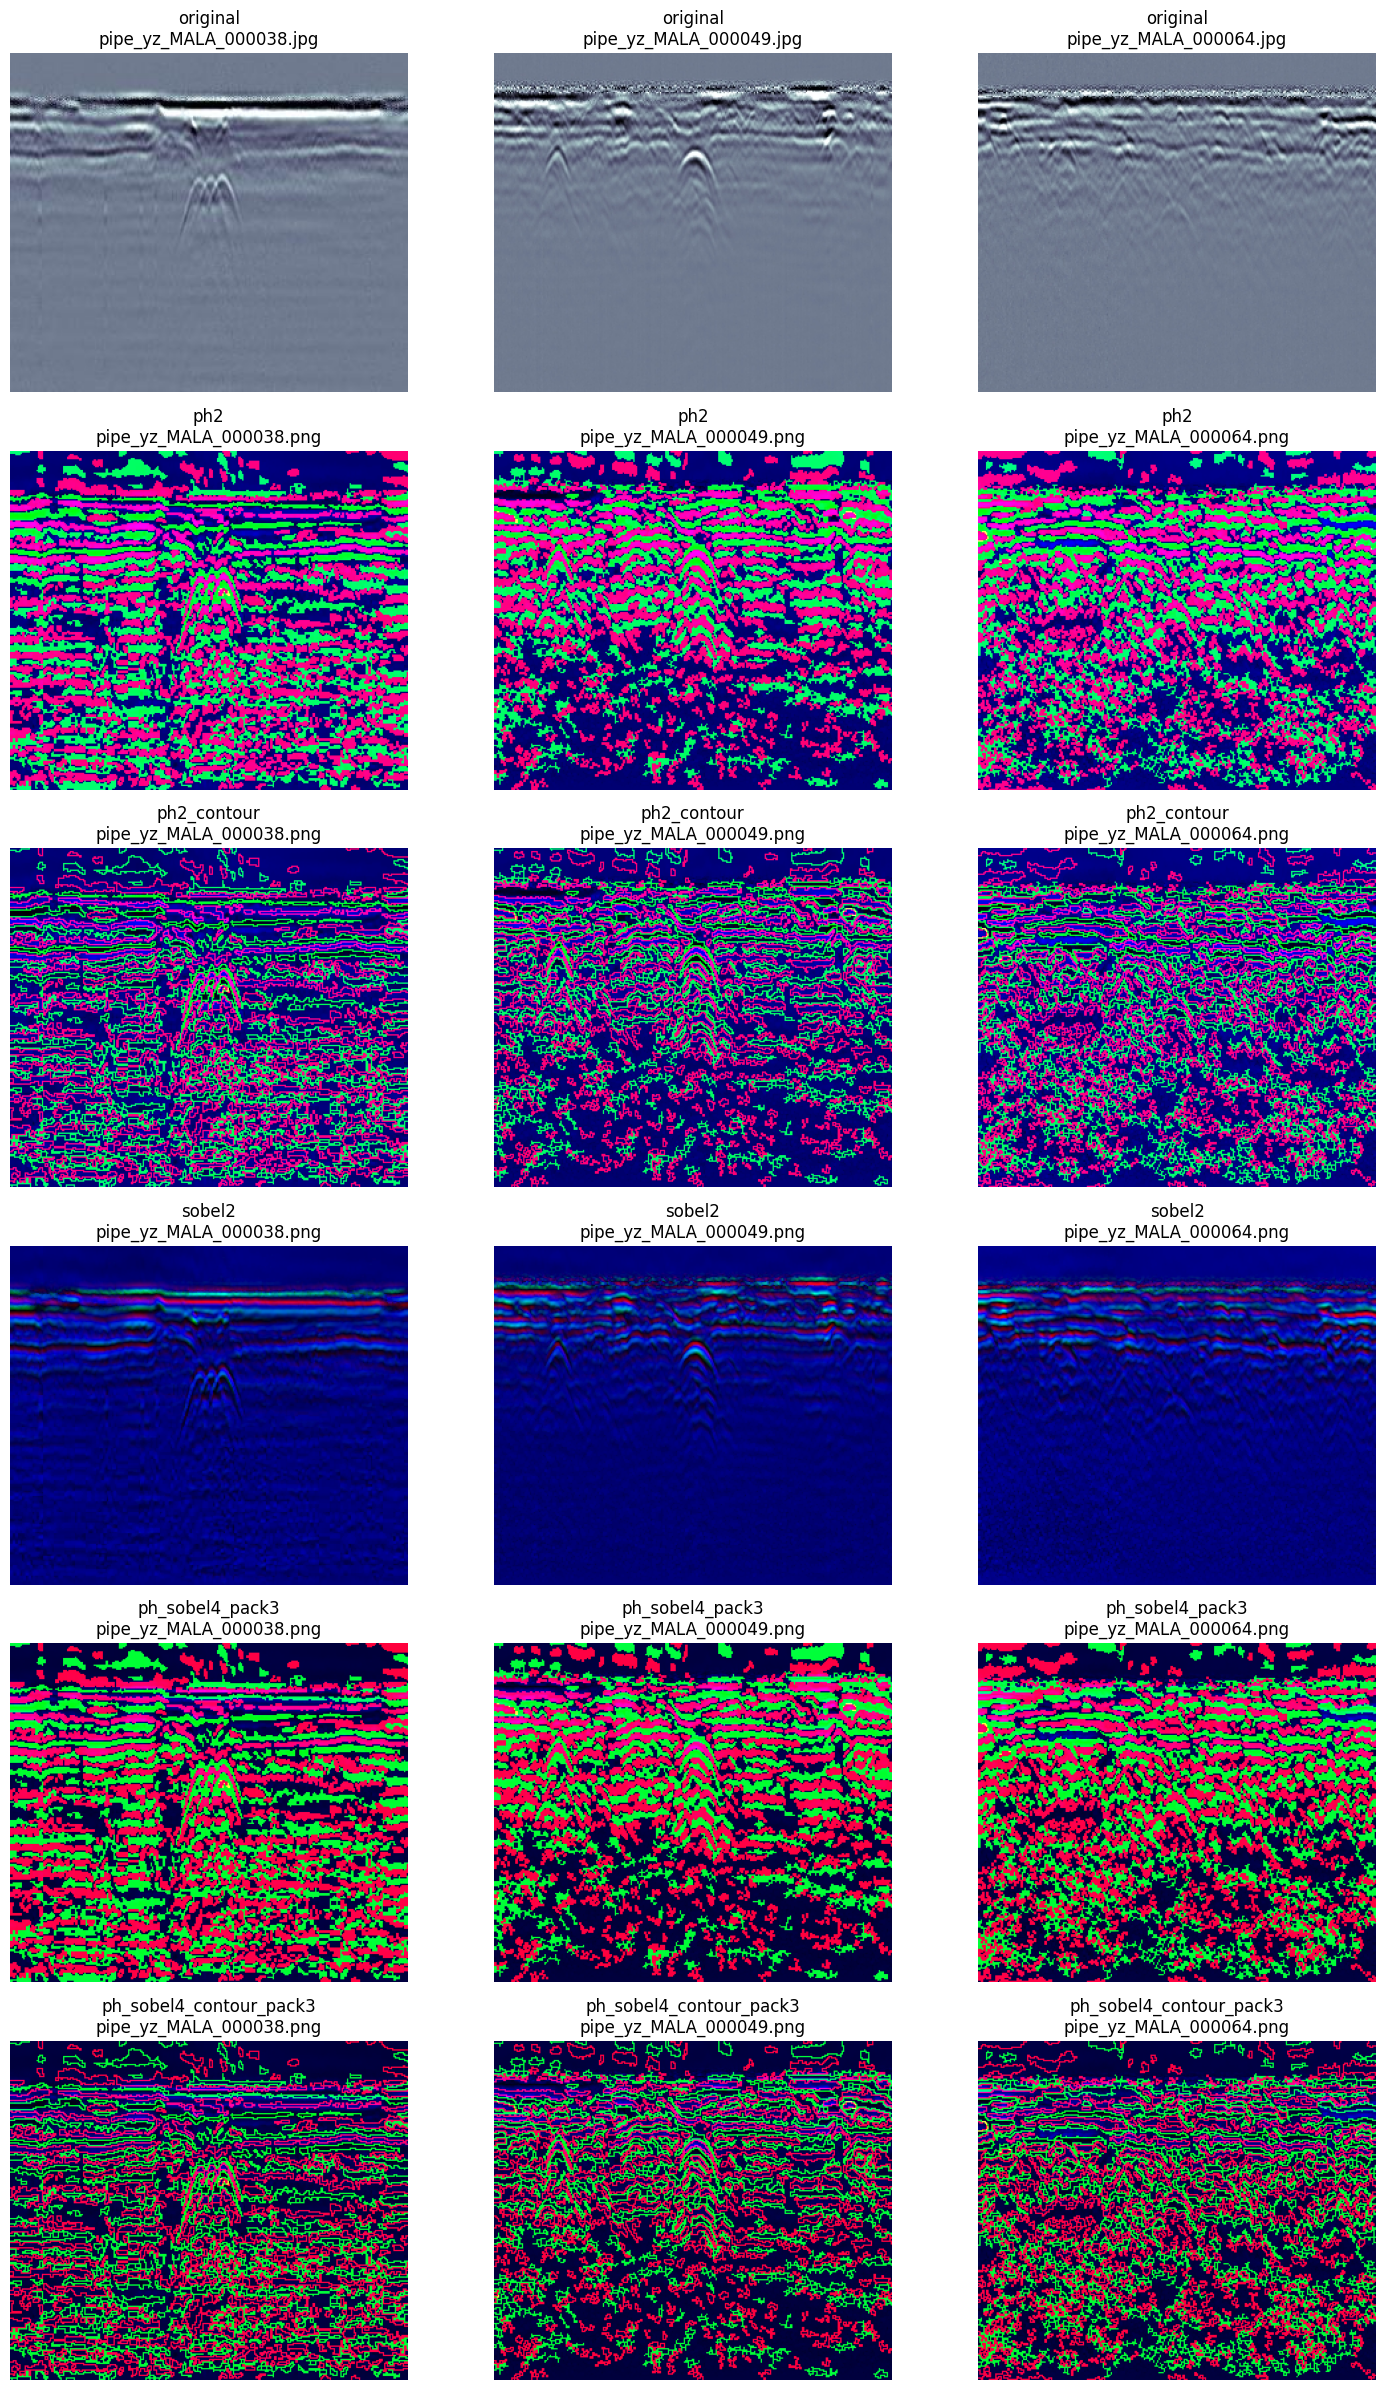

In [ ]:
def show_sample_feature_images(dataset_root, variants=("ph2", "sobel2", "ph_sobel4_pack3"), split="train", n=3):
    plt.figure(figsize=(5 * n, 4 * len(variants)))
    plot_idx = 1

    for variant in variants:
        img_dir = Path(dataset_root) / variant / "images" / split
        imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
        imgs = imgs[:n]

        for img_path in imgs:
            img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = plt.subplot(len(variants), n, plot_idx)
            ax.imshow(img_rgb)
            ax.set_title(f"{variant}\n{img_path.name}")
            ax.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()


show_sample_feature_images(FEATURE_DATASET_ROOT, VARIANTS, split="train", n=3)

## 7. YOLO 모델 학습

각 variant별로 YOLOv8n을 따로 학습합니다.

- `ph2`: PH mask 중심
- `sobel2`: y-gradient 중심
- `ph_sobel4_pack3`: PH + Sobel 결합


In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.4 MB/s eta 0:00:00


In [ ]:
RUNS_DIR

PosixPath('/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr')

In [ ]:
from pathlib import Path

def force_single_class_labels(dataset_dir):
    dataset_dir = Path(dataset_dir)

    for split in ["train", "val", "test"]:
        label_dir = dataset_dir / "labels" / split

        if not label_dir.exists():
            continue

        for label_path in label_dir.glob("*.txt"):
            new_lines = []

            with open(label_path, "r", encoding="utf-8") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                # YOLO bbox label: class x y w h
                if len(parts) >= 5:
                    parts[0] = "0"
                    new_lines.append(" ".join(parts) + "\n")

            with open(label_path, "w", encoding="utf-8") as f:
                f.writelines(new_lines)

    print("모든 라벨 class_id를 0으로 변경 완료:", dataset_dir)

'''
VARIANTS = [
    "ph2",
    "ph2_contour",
    "sobel2",
    "ph_sobel4_pack3",
    "ph_sobel4_contour_pack3",
]
'''
VARIANTS = ["original"]

for variant in VARIANTS:
    dataset_dir = FEATURE_DATASET_ROOT / variant
    force_single_class_labels(dataset_dir)

모든 라벨 class_id를 0으로 변경 완료: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original


In [ ]:
for cache_path in FEATURE_DATASET_ROOT.rglob("*.cache"):
    cache_path.unlink()
    print("삭제:", cache_path)

삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2/labels/train.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2/labels/val.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2/labels/test.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2_contour/labels/train.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2_contour/labels/val.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2_contour/labels/test.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/sobel2/labels/train.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/sobel2/labels/val.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/sobel2/labels/test.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph_sobel4_pack3/labels/train.cache
삭제: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_fea

In [ ]:
from collections import Counter
'''
VARIANTS = [
    "ph2",
    "ph2_contour",
    "sobel2",
    "ph_sobel4_pack3",
    "ph_sobel4_contour_pack3",
    "original",
]
'''
VARIANTS = [

    "original",
]

def check_label_classes(dataset_dir):
    dataset_dir = Path(dataset_dir)
    counter = Counter()

    for label_path in dataset_dir.rglob("labels/**/*.txt"):
        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    counter[parts[0]] += 1

    print(dataset_dir.name, counter)
    return counter
for variant in VARIANTS:
    check_label_classes(FEATURE_DATASET_ROOT / variant)

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
from pathlib import Path

yaml_paths = {
    'original': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/data.yaml'),
  }
"""
yaml_paths = {
    'original': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/data.yaml'),
  'ph2': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2/data.yaml'),
 'ph2_contour': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2_contour/data.yaml'),
 'sobel2': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/sobel2/data.yaml'),
 'ph_sobel4_pack3': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph_sobel4_pack3/data.yaml'),
 'ph_sobel4_contour_pack3': Path('/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph_sobel4_contour_pack3/data.yaml')
  }"""
def train_yolo_variants(
    yaml_paths,
    project_dir,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    base_model="yolov8n.pt",
):
    trained = {}

    for variant, yaml_path in yaml_paths.items():
        print(f"\n========== Train YOLO: {variant} ==========")

        model = YOLO(base_model)

        results = model.train(
            data=str(yaml_path),
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            patience=20,
            device=device,

            # GPR feature image는 RGB 자연영상이 아니므로 색상 augmentation 비활성화
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.0,

            # 구조가 깨지는 강한 augmentation 방지
            degrees=0.0,
            translate=0.05,
            scale=0.20,
            shear=0.0,
            perspective=0.0,
            flipud=0.0,
            fliplr=0.5,
            mosaic=0.5,

            project=str(project_dir),
            name=f"yolo_gpr_{variant}",
            exist_ok=True,
        )

        best_weight = Path(project_dir) / f"yolo_gpr_{variant}" / "weights" / "best.pt"
        trained[variant] = {
            "model": model,
            "results": results,
            "best_weight": best_weight,
            "yaml_path": yaml_path,
        }

        print("best_weight:", best_weight)

    return trained


# 학습 실행
# GPU가 없으면 device="cpu"로 변경하세요.
trained_models = train_yolo_variants(
    yaml_paths=yaml_paths,
    project_dir=RUNS_DIR,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    base_model="yolov8n.pt",
)

trained_models


========== Train YOLO: original ==========
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.

{'original': {'model': YOLO(
    (model): DetectionModel(
      (model): Sequential(
        (0): Conv(
          (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (1): Conv(
          (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (2): C2f(
          (cv1): Conv(
            (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): Batch

## 8. Test set 평가

각 variant별 best weight를 test split으로 평가합니다.
- 추가로 시각화 코드도 들어있음


In [ ]:
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm.auto import tqdm


def find_original_image_by_stem(stem, original_img_dir, image_exts=None):
    """
    stem이 같은 원본 이미지 찾기.
    예:
        feature: pipe_yz_MALA_000013.png
        original: pipe_yz_MALA_000013.jpg
    """
    if image_exts is None:
        image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

    original_img_dir = Path(original_img_dir)

    for ext in image_exts:
        candidate = original_img_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate

    return None


def yolo_label_to_xyxy(label_line, img_w, img_h):
    """
    YOLO label format:
        class x_center y_center width height
    normalized 좌표를 pixel xyxy로 변환.
    """
    parts = label_line.strip().split()

    if len(parts) < 5:
        return None

    cls = int(float(parts[0]))
    xc = float(parts[1]) * img_w
    yc = float(parts[2]) * img_h
    bw = float(parts[3]) * img_w
    bh = float(parts[4]) * img_h

    x1 = int(xc - bw / 2)
    y1 = int(yc - bh / 2)
    x2 = int(xc + bw / 2)
    y2 = int(yc + bh / 2)

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))

    return cls, x1, y1, x2, y2


def draw_gt_boxes(img, label_path, color=(0, 255, 0), thickness=2):
    """
    GT bbox를 초록색으로 그림.
    OpenCV BGR 기준:
        green = (0, 255, 0)
    """
    h, w = img.shape[:2]

    if not Path(label_path).exists():
        return img

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_label_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(
            img,
            f"GT:{cls}",
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

    return img


def draw_pred_boxes(img, boxes, color=(0, 0, 255), thickness=2):
    """
    Prediction bbox를 빨간색으로 그림.
    OpenCV BGR 기준:
        red = (0, 0, 255)
    """
    for box in boxes:
        xyxy = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0].cpu().numpy())
        cls = int(box.cls[0].cpu().numpy())

        x1, y1, x2, y2 = xyxy.astype(int)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(
            img,
            f"P:{cls} {conf:.2f}",
            (x1, min(y2 + 18, img.shape[0] - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

    return img

In [ ]:
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm.auto import tqdm


def find_original_image_by_stem(stem, original_img_dir, image_exts=None):
    """
    stem이 같은 원본 이미지 찾기.
    예:
        feature: pipe_yz_MALA_000013.png
        original: pipe_yz_MALA_000013.jpg
    """
    if image_exts is None:
        image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

    original_img_dir = Path(original_img_dir)

    for ext in image_exts:
        candidate = original_img_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate

    return None


def yolo_label_to_xyxy(label_line, img_w, img_h):
    """
    YOLO label format:
        class x_center y_center width height
    normalized 좌표를 pixel xyxy로 변환.
    """
    parts = label_line.strip().split()

    if len(parts) < 5:
        return None

    cls = int(float(parts[0]))
    xc = float(parts[1]) * img_w
    yc = float(parts[2]) * img_h
    bw = float(parts[3]) * img_w
    bh = float(parts[4]) * img_h

    x1 = int(xc - bw / 2)
    y1 = int(yc - bh / 2)
    x2 = int(xc + bw / 2)
    y2 = int(yc + bh / 2)

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))

    return cls, x1, y1, x2, y2


def draw_gt_boxes(img, label_path, color=(0, 255, 0), thickness=2):
    """
    GT bbox를 초록색으로 그림.
    OpenCV BGR 기준:
        green = (0, 255, 0)
    """
    h, w = img.shape[:2]

    if not Path(label_path).exists():
        return img

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_label_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(
            img,
            f"GT:{cls}",
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

    return img


def draw_pred_boxes(img, boxes, color=(0, 0, 255), thickness=2):
    """
    Prediction bbox를 빨간색으로 그림.
    OpenCV BGR 기준:
        red = (0, 0, 255)
    """
    for box in boxes:
        xyxy = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0].cpu().numpy())
        cls = int(box.cls[0].cpu().numpy())

        x1, y1, x2, y2 = xyxy.astype(int)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(
            img,
            f"P:{cls} {conf:.2f}",
            (x1, min(y2 + 18, img.shape[0] - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

    return img

In [ ]:
def save_prediction_gt_visualizations(
    trained_models,
    original_img_dir,
    output_root,
    split="test",
    imgsz=640,
    device=0,
    conf=0.25,
    max_images=None,
):
    """
    각 variant에 대해:
        feature test image로 예측
        같은 stem의 original image를 불러옴
        original image 위에 GT 초록, pred 빨강으로 표시
        output_root/variant/ 에 저장
    """

    original_img_dir = Path(original_img_dir)
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    for variant, item in trained_models.items():
        print(f"\n========== Save GT/PRED Visualization: {variant} ==========")

        model = YOLO(str(item["best_weight"]))

        yaml_path = Path(item["yaml_path"])
        dataset_dir = yaml_path.parent

        feature_img_dir = dataset_dir / "images" / split
        label_dir = dataset_dir / "labels" / split

        out_dir = output_root / variant
        out_dir.mkdir(parents=True, exist_ok=True)

        feature_images = []
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
            feature_images.extend(sorted(feature_img_dir.glob(f"*{ext}")))

        if max_images is not None:
            feature_images = feature_images[:max_images]

        print("feature_img_dir:", feature_img_dir)
        print("label_dir:", label_dir)
        print("original_img_dir:", original_img_dir)
        print("save_dir:", out_dir)
        print("num images:", len(feature_images))

        missing_original = 0

        for feature_img_path in tqdm(feature_images, desc=f"{variant}/{split}"):
            stem = feature_img_path.stem

            original_path = find_original_image_by_stem(
                stem=stem,
                original_img_dir=original_img_dir,
            )

            if original_path is None:
                print(f"[WARNING] 원본 이미지 없음: {stem}")
                missing_original += 1
                continue

            # 1. 원본 이미지 로드
            original_img = cv2.imread(str(original_path))
            if original_img is None:
                print(f"[WARNING] 원본 이미지 로드 실패: {original_path}")
                continue

            vis_img = original_img.copy()
            ori_h, ori_w = vis_img.shape[:2]

            # 2. feature image로 prediction
            results = model.predict(
                source=str(feature_img_path),
                imgsz=imgsz,
                device=device,
                conf=conf,
                verbose=False,
            )

            result = results[0]

            # 3. prediction box 좌표가 feature image 기준이므로,
            #    feature image와 original image 크기가 다르면 좌표 스케일 조정
            feature_img = cv2.imread(str(feature_img_path))
            feat_h, feat_w = feature_img.shape[:2]

            boxes = result.boxes

            # feature와 original 크기가 같으면 그대로 사용 가능
            # 다르면 boxes 좌표를 original 크기로 변환
            if boxes is not None and len(boxes) > 0:
                if (feat_w != ori_w) or (feat_h != ori_h):
                    scale_x = ori_w / feat_w
                    scale_y = ori_h / feat_h

                    for box in boxes:
                        box.xyxy[0][0] *= scale_x
                        box.xyxy[0][2] *= scale_x
                        box.xyxy[0][1] *= scale_y
                        box.xyxy[0][3] *= scale_y

                vis_img = draw_pred_boxes(
                    vis_img,
                    boxes,
                    color=(0, 0, 255),  # red
                    thickness=2,
                )

            # 4. GT box 그리기
            label_path = label_dir / f"{stem}.txt"

            vis_img = draw_gt_boxes(
                vis_img,
                label_path,
                color=(0, 255, 0),  # green
                thickness=2,
            )

            # 5. 범례 표시
            cv2.putText(
                vis_img,
                "GT: GREEN | PRED: RED",
                (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )

            out_path = out_dir / f"{stem}_gt_pred.png"
            cv2.imwrite(str(out_path), vis_img)

        print(f"[{variant}] missing original:", missing_original)
        print(f"[{variant}] saved to:", out_dir)

In [ ]:
PRED_GT_VIS_DIR = WORK_DIR / "pred_gt_visualizations_original"

save_prediction_gt_visualizations(
    trained_models=trained_models,
    original_img_dir=SRC_IMG_DIR,
    output_root=PRED_GT_VIS_DIR,
    split="test",
    imgsz=640,
    device=0,
    conf=0.25,
    max_images=None,  # 처음엔 20 정도로 테스트해도 됨
)


========== Save GT/PRED Visualization: original ==========
feature_img_dir: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/images/test
label_dir: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/labels/test
original_img_dir: /content/drive/MyDrive/TDA/Final_Pipeline/img_ori
save_dir: /content/drive/MyDrive/TDA/Final_Pipeline/pred_gt_visualizations_original/original
num images: 60


original/test:   0%|          | 0/60 [00:00<?, ?it/s]

[original] missing original: 0
[original] saved to: /content/drive/MyDrive/TDA/Final_Pipeline/pred_gt_visualizations_original/original


## Keypoint Labeling

In [ ]:
from pathlib import Path
import shutil

# =========================
# 경로 설정
# =========================

# YOLO feature dataset의 test 이미지 폴더
TEST_IMAGE_DIR = FEATURE_DATASET_ROOT / "ph2" / "images" / "test"

# 원본 이미지 폴더
ORIGINAL_IMAGE_DIR = SRC_IMG_DIR

# keypoint 라벨링용으로 원본 이미지를 복사할 폴더
KEYPOINT_TEST_ORI_DIR = WORK_DIR / "keypoint_test_original_images"

KEYPOINT_TEST_ORI_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]


def copy_original_images_matching_testset(
    test_image_dir,
    original_image_dir,
    output_dir,
    image_exts=IMAGE_EXTS,
    overwrite=True
):
    test_image_dir = Path(test_image_dir)
    original_image_dir = Path(original_image_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    copied = 0
    missing = 0

    test_images = [
        p for p in sorted(test_image_dir.iterdir())
        if p.suffix.lower() in image_exts
    ]

    print("TEST 이미지 개수:", len(test_images))
    print("TEST_IMAGE_DIR:", test_image_dir)
    print("ORIGINAL_IMAGE_DIR:", original_image_dir)
    print("OUTPUT_DIR:", output_dir)

    for test_img_path in test_images:
        stem = test_img_path.stem

        found_original = None

        # 원본은 jpg일 수도 있고 png일 수도 있으므로 확장자별로 탐색
        for ext in image_exts:
            candidate = original_image_dir / f"{stem}{ext}"
            if candidate.exists():
                found_original = candidate
                break

        if found_original is None:
            print(f"[WARNING] 원본 이미지 없음: {test_img_path.name}")
            missing += 1
            continue

        out_path = output_dir / found_original.name

        if out_path.exists() and not overwrite:
            print(f"[SKIP] 이미 존재: {out_path.name}")
            continue

        shutil.copy2(found_original, out_path)
        copied += 1

    print("\n복사 완료")
    print("복사된 원본 이미지 수:", copied)
    print("못 찾은 원본 이미지 수:", missing)

    return output_dir

In [ ]:
copy_original_images_matching_testset(
    test_image_dir=TEST_IMAGE_DIR,
    original_image_dir=ORIGINAL_IMAGE_DIR,
    output_dir=KEYPOINT_TEST_ORI_DIR,
    overwrite=True
)

TEST 이미지 개수: 60
TEST_IMAGE_DIR: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/ph2/images/test
ORIGINAL_IMAGE_DIR: /content/drive/MyDrive/TDA/Final_Pipeline/img_ori
OUTPUT_DIR: /content/drive/MyDrive/TDA/Final_Pipeline/keypoint_test_original_images

복사 완료
복사된 원본 이미지 수: 60
못 찾은 원본 이미지 수: 0


PosixPath('/content/drive/MyDrive/TDA/Final_Pipeline/keypoint_test_original_images')

## YOLO, Migration

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 79.2 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import os
import json
import cv2
import math
import numpy as np
import pandas as pd
from ultralytics import YOLO

# =========================
# 경로 설정
# =========================
JSON_PATH = Path("/content/drive/MyDrive/TDA/Final_Pipeline/keypoint_json/project-9-at-2026-05-29-10-32-15474ff3.json")

PRED_SAVE_ROOT = WORK_DIR / "predictions"
EVAL_SAVE_ROOT = WORK_DIR / "migration_eval"
EVAL_SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# =========================
# 실제 좌표계 설정
# =========================
REAL_WIDTH_M = 26.0       # 가로 전체 길이 26m
MAX_DEPTH_M = 6.0         # 이미지 하단을 6m로 가정
Y_ZERO_PERCENT = 14.0     # y=14% 지점을 depth=0m로 설정

# threshold region 평가용
MIGRATION_THRESHOLD_RATIO = 0.75
# 예: migration score map에서 max_score * 0.75 이상인 영역을 positive region으로 판단

### 2. 좌표 변환 함수

In [ ]:


def percent_to_pixel(x_percent, y_percent, img_w, img_h):
    x_px = x_percent / 100.0 * img_w
    y_px = y_percent / 100.0 * img_h
    return x_px, y_px


def x_px_to_meter(x_px, img_w):
    return x_px / img_w * REAL_WIDTH_M


def y_px_to_depth_m(y_px, img_h):
    """
    y=14% 위치를 depth=0m로 보고,
    아래로 갈수록 depth가 증가한다고 가정.
    """
    y_zero_px = Y_ZERO_PERCENT / 100.0 * img_h
    depth_m = (y_px - y_zero_px) / (img_h - y_zero_px) * MAX_DEPTH_M
    return depth_m


def calc_pixel_error(pred_x, pred_y, gt_x, gt_y):
    dx_px = pred_x - gt_x
    dy_px = pred_y - gt_y
    dist_px = math.sqrt(dx_px**2 + dy_px**2)
    return dx_px, dy_px, dist_px


def calc_real_error(pred_x, pred_y, gt_x, gt_y, img_w, img_h):
    pred_x_m = x_px_to_meter(pred_x, img_w)
    gt_x_m = x_px_to_meter(gt_x, img_w)

    pred_depth_m = y_px_to_depth_m(pred_y, img_h)
    gt_depth_m = y_px_to_depth_m(gt_y, img_h)

    error_x_m = pred_x_m - gt_x_m
    error_depth_m = pred_depth_m - gt_depth_m
    dist_m = math.sqrt(error_x_m**2 + error_depth_m**2)

    return {
        "pred_x_m": pred_x_m,
        "pred_depth_m": pred_depth_m,
        "gt_x_m": gt_x_m,
        "gt_depth_m": gt_depth_m,
        "error_x_m": error_x_m,
        "error_depth_m": error_depth_m,
        "abs_error_x_m": abs(error_x_m),
        "abs_error_depth_m": abs(error_depth_m),
        "dist_m": dist_m,
    }


def is_point_inside_bbox(x, y, x1, y1, x2, y2):
    return (x1 <= x <= x2) and (y1 <= y <= y2)

import re

def get_gpr_image_id(filename):
    """
    Label Studio JSON 이름:
        fd2be1aa-pipe_yz_MALA_000090.jpg

    test image 이름:
        pipe_yz_MALA_000090.png

    둘 다:
        pipe_yz_MALA_000090
    으로 통일하기 위한 함수.
    """
    name = Path(filename).name
    m = re.search(r"(pipe_yz_MALA_\d+)", name)

    if m:
        return m.group(1)

    return Path(name).stem

In [ ]:
def load_gt_keypoints(json_path):
    """
    Label Studio JSON에서 kp-1 keypoint를 읽고,
    image_id 기준으로 매칭할 수 있도록 정리한다.

    image_id 예:
    fd2be1aa-pipe_yz_MALA_000090.jpg -> pipe_yz_MALA_000090
    pipe_yz_MALA_000090.png         -> pipe_yz_MALA_000090
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []

    for item in data:
        img_path = item.get("img", "")
        image_name = os.path.basename(img_path)
        image_id = get_gpr_image_id(image_name)

        keypoints = item.get("kp-1", [])

        for gt_id, kp in enumerate(keypoints):
            x_percent = float(kp["x"])
            y_percent = float(kp["y"])

            img_w = int(kp.get("original_width", 300))
            img_h = int(kp.get("original_height", 256))

            gt_x_px, gt_y_px = percent_to_pixel(
                x_percent,
                y_percent,
                img_w,
                img_h,
            )

            rows.append({
                "image_name": image_name,
                "image_id": image_id,
                "gt_id": gt_id,

                "gt_x_percent": x_percent,
                "gt_y_percent": y_percent,

                "gt_x_px": gt_x_px,
                "gt_y_px": gt_y_px,

                "img_w": img_w,
                "img_h": img_h,

                "gt_x_m": x_px_to_meter(gt_x_px, img_w),
                "gt_depth_m": y_px_to_depth_m(gt_y_px, img_h),
            })

    return pd.DataFrame(rows)


gt_df = load_gt_keypoints(JSON_PATH)

print("GT 개수:", len(gt_df))
display(gt_df.head())

gt_df[["image_name", "image_id", "gt_x_px", "gt_y_px"]].head()

GT 개수: 151


,image_name,image_id,gt_id,gt_x_percent,gt_y_percent,gt_x_px,gt_y_px,img_w,img_h,gt_x_m,gt_depth_m
0,82b7f3a8-pipe_yz_MALA_000916.jpg,pipe_yz_MALA_000916,0,49.461728,27.407407,148.385185,70.162963,300,256,12.860049,0.935401
1,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,0,17.224691,19.629630,51.674074,50.251852,300,256,4.478420,0.392765
2,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,1,49.777778,45.925926,149.333333,117.570370,300,256,12.942222,2.227390
3,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,2,67.160494,44.259259,201.481481,113.303704,300,256,17.461728,2.111111
4,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,3,76.167901,42.777778,228.503704,109.511111,300,256,19.803654,2.007752


,image_name,image_id,gt_x_px,gt_y_px
0,82b7f3a8-pipe_yz_MALA_000916.jpg,pipe_yz_MALA_000916,148.385185,70.162963
1,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,51.674074,50.251852
2,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,149.333333,117.570370
3,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,201.481481,113.303704
4,39c6f6a6-pipe_yz_MALA_001029.jpg,pipe_yz_MALA_001029,228.503704,109.511111


### 4. YOLO 예측 실행함수

In [ ]:
import shutil

def predict_and_save_yolo(
    variant,
    model_path,
    dataset_root,
    save_root,
    split="test",
    conf=0.25,
    imgsz=640,
    iou=0.45,
    max_det=50,
    clear_existing=True,
):
    model = YOLO(str(model_path))

    source = Path(dataset_root) / variant / "images" / split
    save_root = Path(save_root)
    save_dir = save_root / f"pred_{variant}_{split}"

    # 핵심 수정: 이전 prediction 폴더 삭제
    if clear_existing and save_dir.exists():
        shutil.rmtree(save_dir)
        print("Deleted previous prediction directory:", save_dir)

    results = model.predict(
        source=str(source),
        conf=conf,
        imgsz=imgsz,
        iou=iou,
        max_det=max_det,
        save=True,
        save_txt=True,
        save_conf=True,
        project=str(save_root),
        name=f"pred_{variant}_{split}",
        exist_ok=False,
        verbose=False,
    )

    print("Prediction saved:", save_dir)
    return results, save_dir

### 5, YOLO txt prediction 읽기

In [ ]:
def bbox_iou_xyxy(a, b):
    """
    a, b: dict with bbox_x1, bbox_y1, bbox_x2, bbox_y2
    """
    ax1, ay1, ax2, ay2 = a["bbox_x1"], a["bbox_y1"], a["bbox_x2"], a["bbox_y2"]
    bx1, by1, bx2, by2 = b["bbox_x1"], b["bbox_y1"], b["bbox_x2"], b["bbox_y2"]

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter_area
    if union <= 0:
        return 0.0

    return inter_area / union


def deduplicate_exact_pred_boxes(rows, round_digits=2):
    """
    완전히 같은 bbox가 txt에 반복 저장된 경우 제거.
    confidence가 더 높은 bbox만 남김.
    """
    unique = {}

    for box in rows:
        key = (
            int(box["class"]),
            round(box["bbox_x1"], round_digits),
            round(box["bbox_y1"], round_digits),
            round(box["bbox_x2"], round_digits),
            round(box["bbox_y2"], round_digits),
        )

        if key not in unique:
            unique[key] = box
        else:
            old_conf = unique[key]["conf"] if unique[key]["conf"] is not None else -1
            new_conf = box["conf"] if box["conf"] is not None else -1

            if new_conf > old_conf:
                unique[key] = box

    dedup_rows = list(unique.values())

    for new_id, box in enumerate(dedup_rows):
        box["pred_id"] = new_id

    return dedup_rows


def nms_pred_boxes(rows, iou_thr=0.90):
    """
    거의 같은 위치의 bbox 제거.
    iou_thr=0.90이면 거의 완전히 겹치는 bbox만 제거.
    더 강하게 제거하려면 0.70 또는 0.50 사용.
    """
    if len(rows) == 0:
        return rows

    sorted_rows = sorted(
        rows,
        key=lambda x: x["conf"] if x["conf"] is not None else 0.0,
        reverse=True
    )

    keep = []

    for box in sorted_rows:
        should_keep = True

        for kept in keep:
            if bbox_iou_xyxy(box, kept) >= iou_thr:
                should_keep = False
                break

        if should_keep:
            keep.append(box)

    for new_id, box in enumerate(keep):
        box["pred_id"] = new_id

    return keep


def read_yolo_pred_txt(
    label_path,
    img_w,
    img_h,
    dedup=True,
    nms_iou_thr=0.90,
):
    """
    YOLO prediction txt를 읽어서 pixel bbox로 변환.
    save_conf=True 기준:
    class xc yc w h conf

    추가 수정:
    1. txt 누적에 따른 완전 중복 bbox 제거
    2. IoU가 매우 높은 bbox 제거
    """
    rows = []

    if not Path(label_path).exists():
        return rows

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for pred_id, line in enumerate(lines):
        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))
        xc = float(parts[1])
        yc = float(parts[2])
        bw = float(parts[3])
        bh = float(parts[4])
        conf = float(parts[5]) if len(parts) >= 6 else None

        x1 = (xc - bw / 2) * img_w
        y1 = (yc - bh / 2) * img_h
        x2 = (xc + bw / 2) * img_w
        y2 = (yc + bh / 2) * img_h

        x1 = max(0, min(img_w - 1, x1))
        y1 = max(0, min(img_h - 1, y1))
        x2 = max(0, min(img_w - 1, x2))
        y2 = max(0, min(img_h - 1, y2))

        rows.append({
            "pred_id": pred_id,
            "class": cls,
            "conf": conf,
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "bbox_w": x2 - x1,
            "bbox_h": y2 - y1,
        })

    # =====================================================
    # 핵심 수정 2:
    # txt 안에 누적된 중복 bbox 제거
    # =====================================================
    if dedup:
        before = len(rows)

        rows = deduplicate_exact_pred_boxes(rows, round_digits=2)
        rows = nms_pred_boxes(rows, iou_thr=nms_iou_thr)

        after = len(rows)

        if before != after:
            print(f"[dedup] {Path(label_path).name}: {before} -> {after}")

    return rows

### 6. Migration 함수 자리

In [ ]:
def run_migration_in_bbox(
    image_gray,
    bbox,
    padding=8,
    mask_mode="hard",
    outside_weight=0.15,
    alpha_values=None,
    min_valid_points=10,
):
    """
    bbox 내부에서 기존 hyperbola summation migration 수행.

    return:
    - score_map: migration score map
    - max_x_global: 원본 이미지 기준 migration max point x
    - max_y_global: 원본 이미지 기준 migration max point y
    - max_score: migration max score
    """

    x1, y1, x2, y2 = bbox

    H, W = image_gray.shape[:2]

    # bbox가 이미지 범위 밖으로 나가지 않도록 보정
    x1 = max(0, min(W - 1, x1))
    y1 = max(0, min(H - 1, y1))
    x2 = max(0, min(W - 1, x2))
    y2 = max(0, min(H - 1, y2))

    if x2 <= x1 or y2 <= y1:
        return None, None, None, None

    # ==============================
    # 1. bbox mask 적용
    # ==============================
    masked, inside_mask, outside_mask, padded_bbox = apply_bbox_mask(
        image_gray,
        bbox=(x1, y1, x2, y2),
        padding=padding,
        mask_mode=mask_mode,
        outside_weight=outside_weight,
    )

    # ==============================
    # 2. 기존 migration 수행
    # ==============================
    migration_map, best = image_domain_migration_for_bbox(
        masked,
        padded_bbox,
        alpha_values=alpha_values,
        min_valid_points=min_valid_points,
    )

    if migration_map is None or best is None:
        return None, None, None, None

    max_x_global = best.get("x", None)
    max_y_global = best.get("z", None)
    max_score = best.get("score", None)

    if max_x_global is None or max_y_global is None:
        return migration_map, None, None, max_score

    return migration_map, float(max_x_global), float(max_y_global), float(max_score)

### 7. Threshold 이상 영역 안에 GT가 있는지 확인

In [ ]:
def check_gt_in_threshold_region_global(
    score_map,
    gt_x_px,
    gt_y_px,
    threshold_ratio=0.75,
):
    """
    migration_map이 원본 이미지 전체 크기일 때 사용한다.

    GT keypoint가 migration threshold 영역에 포함되는지 확인한다.
    """
    if score_map is None or score_map.size == 0:
        return False, None, None

    h, w = score_map.shape[:2]

    gt_x_i = int(round(gt_x_px))
    gt_y_i = int(round(gt_y_px))

    if not (0 <= gt_x_i < w and 0 <= gt_y_i < h):
        return False, None, None

    max_score = float(np.max(score_map))
    threshold_value = max_score * threshold_ratio

    gt_score = float(score_map[gt_y_i, gt_x_i])
    inside_threshold_region = gt_score >= threshold_value

    return inside_threshold_region, gt_score, threshold_value

### 8. Variant 하나에 대해 평가하는 함수

In [ ]:
def save_gt_migration_overlay(
    img,
    image_name,
    variant,
    bbox,
    bbox_idx,
    all_gt_df,
    matched_gt,
    pred_x,
    pred_y,
    score_map,
    threshold_ratio,
    error_info,
    save_root,
    reason="ok",
):
    """
    원본 test 이미지 위에 다음을 저장한다.

    - YOLO bbox: 빨간 사각형
    - 전체 GT keypoint: 초록 원
    - matched GT keypoint: 채워진 초록 점
    - migration max point: 빨간 X
    - threshold region: 빨간 반투명 영역
    """

    save_root = Path(save_root)

    if reason == "ok":
        save_dir = save_root / "visualizations" / variant
    else:
        save_dir = save_root / "visualizations_false_detection" / variant

    save_dir.mkdir(parents=True, exist_ok=True)

    x1, y1, x2, y2 = bbox

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # =====================================================
    # 1) 원본 이미지 + bbox + GT + migration max point
    # =====================================================
    axes[0].imshow(img, cmap="gray")

    axes[0].add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="red",
            linewidth=2,
            label="YOLO bbox",
        )
    )

    # 이미지 안의 전체 GT keypoint 표시
    if all_gt_df is not None and len(all_gt_df) > 0:
        axes[0].scatter(
            all_gt_df["gt_x_px"],
            all_gt_df["gt_y_px"],
            facecolors="none",
            edgecolors="lime",
            s=90,
            linewidths=2,
            label="All GT",
        )

    # bbox 내부에서 matching된 GT 표시
    if matched_gt is not None:
        gt_x = float(matched_gt["gt_x_px"])
        gt_y = float(matched_gt["gt_y_px"])

        axes[0].scatter(
            [gt_x],
            [gt_y],
            c="lime",
            s=70,
            marker="o",
            label="Matched GT",
        )

    # migration max point 표시
    if pred_x is not None and pred_y is not None:
        axes[0].scatter(
            [pred_x],
            [pred_y],
            c="red",
            s=110,
            marker="x",
            linewidths=2.5,
            label="Migration max",
        )

    title = f"{image_name} | bbox {bbox_idx}\n{reason}"

    if error_info is not None:
        title += (
            f"\nGT depth={error_info['gt_depth_m']:.3f}m | "
            f"Pred depth={error_info['pred_depth_m']:.3f}m"
            f"\nDepth err={error_info['error_depth_m']:.3f}m | "
            f"X err={error_info['error_x_m']:.3f}m | "
            f"Dist={error_info['dist_m']:.3f}m"
        )

    axes[0].set_title(title)
    axes[0].legend(loc="lower right")
    axes[0].axis("off")

    # =====================================================
    # 2) migration score map
    # =====================================================
    if score_map is not None:
        axes[1].imshow(score_map, cmap="hot")

        if matched_gt is not None:
            axes[1].scatter(
                [float(matched_gt["gt_x_px"])],
                [float(matched_gt["gt_y_px"])],
                facecolors="none",
                edgecolors="lime",
                s=110,
                linewidths=2,
                label="Matched GT",
            )

        if pred_x is not None and pred_y is not None:
            axes[1].scatter(
                [pred_x],
                [pred_y],
                c="cyan",
                s=110,
                marker="x",
                linewidths=2.5,
                label="Migration max",
            )

        axes[1].set_title("Migration score map")
        axes[1].legend(loc="lower right")
        axes[1].axis("off")
    else:
        axes[1].imshow(img, cmap="gray")
        axes[1].set_title("No migration map")
        axes[1].axis("off")

    # =====================================================
    # 3) threshold region overlay
    # =====================================================
    axes[2].imshow(img, cmap="gray")

    if score_map is not None:
        threshold_value = float(np.max(score_map)) * threshold_ratio
        threshold_mask = score_map >= threshold_value

        # score_map과 img 크기가 같은 경우에만 overlay
        if threshold_mask.shape[:2] == img.shape[:2]:
            overlay = np.zeros((*threshold_mask.shape, 4), dtype=np.float32)
            overlay[..., 0] = 1.0
            overlay[..., 3] = threshold_mask.astype(np.float32) * 0.35
            axes[2].imshow(overlay)
        else:
            axes[2].imshow(threshold_mask, cmap="gray", alpha=0.45)

    if all_gt_df is not None and len(all_gt_df) > 0:
        axes[2].scatter(
            all_gt_df["gt_x_px"],
            all_gt_df["gt_y_px"],
            facecolors="none",
            edgecolors="lime",
            s=90,
            linewidths=2,
            label="All GT",
        )

    if pred_x is not None and pred_y is not None:
        axes[2].scatter(
            [pred_x],
            [pred_y],
            c="cyan",
            s=110,
            marker="x",
            linewidths=2.5,
            label="Migration max",
        )

    axes[2].set_title(f"Threshold region >= max * {threshold_ratio}")
    handles, labels = axes[2].get_legend_handles_labels()
    if len(handles) > 0:
        axes[2].legend(loc="lower right")
    axes[2].axis("off")

    plt.tight_layout()

    out_path = save_dir / f"{Path(image_name).stem}_bbox{bbox_idx}_{reason}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)

    return out_path

In [ ]:
def evaluate_variant_predictions(
    variant,
    dataset_root,
    pred_save_dir,
    gt_df,
    split="test",
    threshold_ratio=0.75,
    save_visualization=True,
    one_to_one_gt_matching=True,
):
    image_dir = Path(dataset_root) / variant / "images" / split
    label_dir = Path(pred_save_dir) / "labels"

    rows = []

    image_paths = sorted(
        list(image_dir.glob("*.jpg")) +
        list(image_dir.glob("*.png")) +
        list(image_dir.glob("*.jpeg"))
    )

    print("image_dir:", image_dir)
    print("label_dir:", label_dir)
    print("num images:", len(image_paths))

    for image_path in image_paths:
        image_name = image_path.name
        image_id = get_gpr_image_id(image_name)

        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("이미지 로드 실패:", image_path)
            continue

        img_h, img_w = img.shape[:2]

        label_path = label_dir / f"{image_path.stem}.txt"
        pred_boxes = read_yolo_pred_txt(label_path, img_w, img_h)

        # 핵심 수정:
        # 기존 image_name 직접 비교 대신 image_id 기준으로 매칭
        image_gt_df = gt_df[gt_df["image_id"] == image_id].copy()

        # 같은 GT가 여러 bbox에 반복 매칭되는 것을 방지
        used_gt_ids = set()

        covered_gt_ids = set()

        # prediction이 없는 경우
        if len(pred_boxes) == 0:
            if len(image_gt_df) > 0:
                for _, missed_gt in image_gt_df.iterrows():
                    rows.append({
                        "variant": variant,
                        "image_name": image_name,
                        "image_id": image_id,

                        "has_prediction": False,
                        "pred_id": None,
                        "class": None,
                        "conf": None,

                        "bbox_x1": None,
                        "bbox_y1": None,
                        "bbox_x2": None,
                        "bbox_y2": None,
                        "bbox_w": None,
                        "bbox_h": None,

                        "num_gt_in_image": len(image_gt_df),
                        "num_gt_inside_bbox": 0,

                        "bbox_has_gt": False,
                        "is_false_detection": False,
                        "is_duplicate_detection": False,
                        "is_missed_detection": True,

                        "reason": "missed_detection",

                        "missed_gt_id": int(missed_gt["gt_id"]),
                        "missed_gt_x_px": float(missed_gt["gt_x_px"]),
                        "missed_gt_y_px": float(missed_gt["gt_y_px"]),

                        "matched_gt_id": None,
                        "gt_x_px": None,
                        "gt_y_px": None,

                        "migration_max_x_px": None,
                        "migration_max_y_px": None,
                        "migration_max_score": None,

                        "dx_px": None,
                        "dy_px": None,
                        "dist_px": None,

                        "error_x_m": None,
                        "error_depth_m": None,
                        "abs_error_x_m": None,
                        "abs_error_depth_m": None,
                        "dist_m": None,

                        "threshold_ratio": threshold_ratio,
                        "threshold_value": None,
                        "threshold_region_has_gt": None,
                        "gt_score_in_migration_map": None,

                        "visualization_path": None,
                    })
            else:
                rows.append({
                    "variant": variant,
                    "image_name": image_name,
                    "image_id": image_id,

                    "has_prediction": False,
                    "num_gt_in_image": 0,
                    "bbox_has_gt": False,
                    "is_false_detection": False,
                    "is_duplicate_detection": False,
                    "is_missed_detection": False,

                    "reason": "no_prediction",
                    "visualization_path": None,
                })

            continue

        for box in pred_boxes:
            x1 = box["bbox_x1"]
            y1 = box["bbox_y1"]
            x2 = box["bbox_x2"]
            y2 = box["bbox_y2"]

            bbox = (x1, y1, x2, y2)
            bbox_idx = box["pred_id"]

            # =====================================================
            # bbox 안에 들어온 GT keypoint 찾기
            # =====================================================
            if len(image_gt_df) > 0:
                gt_inside_df = image_gt_df[
                    (image_gt_df["gt_x_px"] >= x1) &
                    (image_gt_df["gt_x_px"] <= x2) &
                    (image_gt_df["gt_y_px"] >= y1) &
                    (image_gt_df["gt_y_px"] <= y2)
                ].copy()
            else:
                gt_inside_df = pd.DataFrame()


            bbox_has_gt = len(gt_inside_df) > 0

            # =====================================================
            # 추가:
            # bbox 안에 들어온 GT는 covered_gt_ids에 기록
            # 나중에 여기에 없는 GT만 missed_detection으로 처리
            # =====================================================
            if bbox_has_gt:
              covered_gt_ids.update(
                  gt_inside_df["gt_id"].astype(int).tolist()
              )

            # =====================================================
            # 이미 다른 bbox에 매칭된 GT는 제외
            # =====================================================
            if one_to_one_gt_matching and len(gt_inside_df) > 0:
                gt_inside_unused_df = gt_inside_df[
                    ~gt_inside_df["gt_id"].astype(int).isin(used_gt_ids)
                ].copy()
            else:
                gt_inside_unused_df = gt_inside_df.copy()

            bbox_has_unused_gt = len(gt_inside_unused_df) > 0

            # =====================================================
            # bbox 안에 GT가 없으면 false detection으로 저장
            # 그래도 시각화는 저장해서 실제로 왜 없는지 확인
            # =====================================================
            if not bbox_has_gt:
                vis_path = None

                if save_visualization:
                    vis_path = save_gt_migration_overlay(
                        img=img,
                        image_name=image_name,
                        variant=variant,
                        bbox=bbox,
                        bbox_idx=bbox_idx,
                        all_gt_df=image_gt_df,
                        matched_gt=None,
                        pred_x=None,
                        pred_y=None,
                        score_map=None,
                        threshold_ratio=threshold_ratio,
                        error_info=None,
                        save_root=EVAL_SAVE_ROOT,
                        reason="bbox_has_no_gt",
                    )

                rows.append({
                    "variant": variant,
                    "image_name": image_name,
                    "image_id": image_id,
                    "has_prediction": True,
                    **box,

                    "num_gt_in_image": len(image_gt_df),
                    "num_gt_inside_bbox": 0,

                    "bbox_has_gt": False,
                    "is_false_detection": True,
                    "reason": "bbox_has_no_gt_keypoint",

                    "visualization_path": None if vis_path is None else str(vis_path),
                })
                continue

            # =====================================================
            # bbox 안에 GT는 있지만, 이미 다른 bbox에 매칭된 GT뿐인 경우
            # 즉, 같은 GT를 또 잡은 중복 탐지
            # =====================================================
            if not bbox_has_unused_gt:
                vis_path = None

                if save_visualization:
                    vis_path = save_gt_migration_overlay(
                        img=img,
                        image_name=image_name,
                        variant=variant,
                        bbox=bbox,
                        bbox_idx=bbox_idx,
                        all_gt_df=image_gt_df,
                        matched_gt=None,
                        pred_x=None,
                        pred_y=None,
                        score_map=None,
                        threshold_ratio=threshold_ratio,
                        error_info=None,
                        save_root=EVAL_SAVE_ROOT,
                        reason="duplicate_same_gt",
                    )

                rows.append({
                    "variant": variant,
                    "image_name": image_name,
                    "image_id": image_id,
                    "has_prediction": True,
                    **box,

                    "num_gt_in_image": len(image_gt_df),
                    "num_gt_inside_bbox": len(gt_inside_df),

                    "bbox_has_gt": True,
                    "is_false_detection": True,
                    "is_duplicate_detection": True,
                    "reason": "duplicate_same_gt",

                    "matched_gt_id": None,
                    "visualization_path": None if vis_path is None else str(vis_path),
                })
                continue

            # =====================================================
            # bbox 안에 GT가 있는 경우 migration 수행
            # =====================================================
            score_map, max_x, max_y, max_score = run_migration_in_bbox(
                image_gray=img,
                bbox=bbox,
                padding=8,
                mask_mode="hard",
                outside_weight=0.15,
                alpha_values=np.linspace(0.02, 1.5, 80),
                min_valid_points=10,
            )

            if score_map is None or max_x is None or max_y is None:
                vis_path = None

                if save_visualization:
                    vis_path = save_gt_migration_overlay(
                        img=img,
                        image_name=image_name,
                        variant=variant,
                        bbox=bbox,
                        bbox_idx=bbox_idx,
                        all_gt_df=image_gt_df,
                        matched_gt=None,
                        pred_x=None,
                        pred_y=None,
                        score_map=None,
                        threshold_ratio=threshold_ratio,
                        error_info=None,
                        save_root=EVAL_SAVE_ROOT,
                        reason="migration_failed",
                    )

                rows.append({
                    "variant": variant,
                    "image_name": image_name,
                    "image_id": image_id,
                    "has_prediction": True,
                    **box,

                    "num_gt_in_image": len(image_gt_df),
                    "num_gt_inside_bbox": len(gt_inside_df),

                    "bbox_has_gt": True,
                    "is_false_detection": False,
                    "reason": "migration_failed",

                    "visualization_path": None if vis_path is None else str(vis_path),
                })
                continue

            # =====================================================
            # bbox 안의 GT 중 migration max point와 가장 가까운 GT 선택
            # =====================================================
            best_gt = None
            best_dist_px = float("inf")

            for _, gt in gt_inside_unused_df.iterrows():
                gt_x = float(gt["gt_x_px"])
                gt_y = float(gt["gt_y_px"])

                _, _, candidate_dist_px = calc_pixel_error(
                    max_x,
                    max_y,
                    gt_x,
                    gt_y,
                )

                if candidate_dist_px < best_dist_px:
                    best_dist_px = candidate_dist_px
                    best_gt = gt

            gt_x = float(best_gt["gt_x_px"])
            gt_y = float(best_gt["gt_y_px"])
            gt_id = int(best_gt["gt_id"])
            used_gt_ids.add(gt_id)

            dx_px, dy_px, dist_px = calc_pixel_error(max_x, max_y, gt_x, gt_y)
            real_err = calc_real_error(max_x, max_y, gt_x, gt_y, img_w, img_h)

            threshold_region_has_gt, gt_score, threshold_value = check_gt_in_threshold_region_global(
                score_map=score_map,
                gt_x_px=gt_x,
                gt_y_px=gt_y,
                threshold_ratio=threshold_ratio,
            )

            error_info = {
                "gt_depth_m": real_err["gt_depth_m"],
                "pred_depth_m": real_err["pred_depth_m"],
                "error_depth_m": real_err["error_depth_m"],
                "error_x_m": real_err["error_x_m"],
                "dist_m": real_err["dist_m"],
            }

            vis_path = None

            if save_visualization:
                vis_path = save_gt_migration_overlay(
                    img=img,
                    image_name=image_name,
                    variant=variant,
                    bbox=bbox,
                    bbox_idx=bbox_idx,
                    all_gt_df=image_gt_df,
                    matched_gt=best_gt,
                    pred_x=max_x,
                    pred_y=max_y,
                    score_map=score_map,
                    threshold_ratio=threshold_ratio,
                    error_info=error_info,
                    save_root=EVAL_SAVE_ROOT,
                    reason="ok",
                )

            rows.append({
                "variant": variant,
                "image_name": image_name,
                "image_id": image_id,
                "has_prediction": True,
                **box,

                "num_gt_in_image": len(image_gt_df),
                "num_gt_inside_bbox": len(gt_inside_df),

                "bbox_has_gt": True,
                "is_false_detection": False,
                "reason": "ok",

                "matched_gt_id": gt_id,

                "gt_x_px": gt_x,
                "gt_y_px": gt_y,
                "gt_x_m": real_err["gt_x_m"],
                "gt_depth_m": real_err["gt_depth_m"],

                "migration_max_x_px": float(max_x),
                "migration_max_y_px": float(max_y),
                "migration_max_score": float(max_score),

                "pred_x_m": real_err["pred_x_m"],
                "pred_depth_m": real_err["pred_depth_m"],

                "dx_px": dx_px,
                "dy_px": dy_px,
                "dist_px": dist_px,

                "error_x_m": real_err["error_x_m"],
                "error_depth_m": real_err["error_depth_m"],
                "abs_error_x_m": real_err["abs_error_x_m"],
                "abs_error_depth_m": real_err["abs_error_depth_m"],
                "dist_m": real_err["dist_m"],

                "threshold_ratio": threshold_ratio,
                "threshold_value": threshold_value,
                "threshold_region_has_gt": threshold_region_has_gt,
                "gt_score_in_migration_map": gt_score,

                "visualization_path": None if vis_path is None else str(vis_path),
            })

        # =====================================================
        # 이미지 내 GT 중 어떤 predicted bbox에도 포함되지 않은 GT 기록
        # → missed_detection
        # =====================================================
        if len(image_gt_df) > 0:
            missed_gt_df = image_gt_df[
                ~image_gt_df["gt_id"].astype(int).isin(covered_gt_ids)
            ].copy()

            for _, missed_gt in missed_gt_df.iterrows():
                rows.append({
                    "variant": variant,
                    "image_name": image_name,
                    "image_id": image_id,

                    "has_prediction": False,
                    "pred_id": None,
                    "class": None,
                    "conf": None,

                    "bbox_x1": None,
                    "bbox_y1": None,
                    "bbox_x2": None,
                    "bbox_y2": None,
                    "bbox_w": None,
                    "bbox_h": None,

                    "num_gt_in_image": len(image_gt_df),
                    "num_gt_inside_bbox": 0,

                    "bbox_has_gt": False,
                    "is_false_detection": False,
                    "is_duplicate_detection": False,
                    "is_missed_detection": True,

                    "reason": "missed_detection",

                    "missed_gt_id": int(missed_gt["gt_id"]),
                    "missed_gt_x_px": float(missed_gt["gt_x_px"]),
                    "missed_gt_y_px": float(missed_gt["gt_y_px"]),

                    "matched_gt_id": None,
                    "gt_x_px": None,
                    "gt_y_px": None,

                    "migration_max_x_px": None,
                    "migration_max_y_px": None,
                    "migration_max_score": None,

                    "dx_px": None,
                    "dy_px": None,
                    "dist_px": None,

                    "error_x_m": None,
                    "error_depth_m": None,
                    "abs_error_x_m": None,
                    "abs_error_depth_m": None,
                    "dist_m": None,

                    "threshold_ratio": threshold_ratio,
                    "threshold_value": None,
                    "threshold_region_has_gt": None,
                    "gt_score_in_migration_map": None,

                    "visualization_path": None,
                })

    return pd.DataFrame(rows)

### 9. 모든 variant에 대해 YOLO 예측 + migration 평가

In [ ]:
from pathlib import Path

trained_models = {
    "original": {
        "best_weight": Path("/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr/yolo_gpr_original/weights/best.pt"),
    },
    "ph2": {
        "best_weight": Path("/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr/yolo_gpr_ph2/weights/best.pt"),
    },
    "sobel2": {
        "best_weight": Path("/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr/yolo_gpr_sobel2/weights/best.pt"),
    },
    "ph2_contour": {
        "best_weight": Path("/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr/yolo_gpr_ph2_contour/weights/best.pt"),
    },
    "ph_sobel4_pack3": {
        "best_weight": Path("/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr/yolo_gpr_ph_sobel4_pack3/weights/best.pt"),
    },
    "ph_sobel4_contour_pack3": {
        "best_weight": Path("/content/drive/MyDrive/TDA/Final_Pipeline/runs_gpr/yolo_gpr_ph_sobel4_contour_pack3/weights/best.pt"),
    },
}

In [ ]:
all_eval_dfs = []

for variant, item in trained_models.items():
    print(f"\n==============================")
    print(f"Variant: {variant}")
    print(f"==============================")

    model_path = item["best_weight"]

    pred_results, pred_save_dir = predict_and_save_yolo(
        variant=variant,
        model_path=model_path,
        dataset_root=FEATURE_DATASET_ROOT,
        save_root=PRED_SAVE_ROOT,
        split="test",
        conf=0.25,
        imgsz=640,
        iou=0.45,
        max_det=50,
        clear_existing=True,
    )

    eval_df = evaluate_variant_predictions(
        variant=variant,
        dataset_root=FEATURE_DATASET_ROOT,
        pred_save_dir=pred_save_dir,
        gt_df=gt_df,
        split="test",
        threshold_ratio=MIGRATION_THRESHOLD_RATIO,
        save_visualization=True,
        one_to_one_gt_matching=True
    )

    variant_csv_path = EVAL_SAVE_ROOT / f"migration_eval_{variant}.csv"
    eval_df.to_csv(variant_csv_path, index=False, encoding="utf-8-sig")

    print("Saved:", variant_csv_path)

    all_eval_dfs.append(eval_df)

all_eval_df = pd.concat(all_eval_dfs, ignore_index=True)
all_eval_csv_path = EVAL_SAVE_ROOT / "migration_eval_all_variants.csv"
all_eval_df.to_csv(all_eval_csv_path, index=False, encoding="utf-8-sig")

print("All variant eval saved:", all_eval_csv_path)
all_eval_df.head()


Variant: original
Deleted previous prediction directory: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_original_test
Results saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_original_test
56 labels saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_original_test/labels
Prediction saved: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_original_test
image_dir: /content/drive/MyDrive/TDA/Final_Pipeline/yolo_feature_datasets/original/images/test
label_dir: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_original_test/labels
num images: 60
Saved: /content/drive/MyDrive/TDA/Final_Pipeline/migration_eval/migration_eval_original.csv

Variant: ph2
Deleted previous prediction directory: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test
Results saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test
58 labels saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test/la

,variant,image_name,image_id,has_prediction,pred_id,class,conf,bbox_x1,bbox_y1,bbox_x2,...,threshold_ratio,threshold_value,threshold_region_has_gt,gt_score_in_migration_map,visualization_path,is_duplicate_detection,is_missed_detection,missed_gt_id,missed_gt_x_px,missed_gt_y_px
0,original,pipe_yz_MALA_000090.jpg,pipe_yz_MALA_000090,True,0.0,0.0,0.741381,142.075245,82.245632,161.036955,...,0.75,0.75,True,0.981009,/content/drive/MyDrive/TDA/Final_Pipeline/migr...,NaN,NaN,NaN,NaN,NaN
1,original,pipe_yz_MALA_000090.jpg,pipe_yz_MALA_000090,True,1.0,0.0,0.347115,69.259935,74.643725,82.781865,...,0.75,0.75,False,0.587548,/content/drive/MyDrive/TDA/Final_Pipeline/migr...,NaN,NaN,NaN,NaN,NaN
2,original,pipe_yz_MALA_000090.jpg,pipe_yz_MALA_000090,False,NaN,NaN,NaN,NaN,NaN,NaN,...,0.75,NaN,None,NaN,None,False,True,0.0,262.162963,40.770370
3,original,pipe_yz_MALA_000090.jpg,pipe_yz_MALA_000090,False,NaN,NaN,NaN,NaN,NaN,NaN,...,0.75,NaN,None,NaN,None,False,True,1.0,282.074074,55.940741
4,original,pipe_yz_MALA_000090.jpg,pipe_yz_MALA_000090,False,NaN,NaN,NaN,NaN,NaN,NaN,...,0.75,NaN,None,NaN,None,False,True,4.0,85.807407,79.170370


Results saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test
58 labels saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test/labels
Prediction saved: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test

### 10. Variant별 요약 결과

In [ ]:
def summarize_eval(all_eval_df):
    valid = all_eval_df[
        (all_eval_df["has_prediction"] == True) &
        (all_eval_df["bbox_has_gt"] == True) &
        (all_eval_df["reason"] == "ok")
    ].copy()

    summary_rows = []

    for variant, df in all_eval_df.groupby("variant"):
        total_pred = len(df[df["has_prediction"] == True])
        false_det = len(df[df["is_false_detection"] == True])

        if "is_duplicate_detection" in df.columns:
            duplicate_det = len(df[df["is_duplicate_detection"] == True])
        else:
            duplicate_det = 0

        bbox_no_gt_det = len(df[df["reason"] == "bbox_has_no_gt_keypoint"])

        valid_df = valid[valid["variant"] == variant]

        if len(valid_df) == 0:
            summary_rows.append({
                "variant": variant,
                "total_predictions": total_pred,
                "false_detections": false_det,
                "duplicate_detections": duplicate_det,
                "bbox_no_gt_detections": bbox_no_gt_det,
                "valid_migration_eval_count": len(valid_df),
                "bbox_gt_hit_rate": None,
                "threshold_region_gt_hit_rate": None,
                "mean_abs_error_x_m": None,
                "mean_abs_error_depth_m": None,
                "mean_dist_m": None,
                "mean_dist_px": None,
            })
            continue

        bbox_gt_hit_rate = len(valid_df) / total_pred if total_pred > 0 else None
        threshold_hit_rate = valid_df["threshold_region_has_gt"].mean()

        summary_rows.append({
            "variant": variant,
            "total_predictions": total_pred,
            "false_detections": false_det,
            "valid_migration_eval_count": len(valid_df),

            "bbox_gt_hit_rate": bbox_gt_hit_rate,
            "threshold_region_gt_hit_rate": threshold_hit_rate,

            "mean_abs_error_x_m": valid_df["abs_error_x_m"].mean(),
            "median_abs_error_x_m": valid_df["abs_error_x_m"].median(),

            "mean_abs_error_depth_m": valid_df["abs_error_depth_m"].mean(),
            "median_abs_error_depth_m": valid_df["abs_error_depth_m"].median(),

            "mean_dist_m": valid_df["dist_m"].mean(),
            "median_dist_m": valid_df["dist_m"].median(),

            "mean_dist_px": valid_df["dist_px"].mean(),
            "median_dist_px": valid_df["dist_px"].median(),
        })

    return pd.DataFrame(summary_rows)


summary_df = summarize_eval(all_eval_df)

summary_csv_path = EVAL_SAVE_ROOT / "migration_eval_summary_by_variant.csv"
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

summary_df

,variant,total_predictions,false_detections,valid_migration_eval_count,bbox_gt_hit_rate,threshold_region_gt_hit_rate,mean_abs_error_x_m,median_abs_error_x_m,mean_abs_error_depth_m,median_abs_error_depth_m,mean_dist_m,median_dist_m,mean_dist_px,median_dist_px
0,original,95,12,83,0.873684,0.602410,1.240490,1.315407,0.251432,0.234577,1.284901,1.351681,18.023495,18.644976
1,ph2,151,43,108,0.715232,0.407407,1.048417,1.110617,0.284561,0.283228,1.111124,1.168414,16.994708,17.585667
2,ph2_contour,147,42,105,0.714286,0.276190,0.981544,1.127309,0.265142,0.239422,1.053495,1.162622,16.243173,16.266063
3,ph_sobel4_contour_pack3,119,24,95,0.798319,0.210526,1.052258,1.152988,0.268075,0.239220,1.116335,1.228395,16.830759,16.971500
4,ph_sobel4_pack3,140,40,100,0.714286,0.360000,0.971848,1.116074,0.290984,0.283228,1.053953,1.166114,16.736423,17.159300
5,sobel2,100,13,87,0.870000,0.275862,1.297808,1.369975,0.275144,0.250525,1.347583,1.392615,18.976408,18.892162


In [ ]:
summary_csv_path

PosixPath('/content/drive/MyDrive/TDA/Final_Pipeline/migration_eval/migration_eval_summary_by_variant.csv')

In [ ]:
print(PRED_SAVE_ROOT / "pred_ph2_test")

/content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_ph2_test


### 1. 시각화 저장 함수 추가

## 9. YOLO 추론 결과 저장

학습된 모델 중 원하는 variant를 골라 test image에 대해 bbox detection 결과를 저장합니다.


In [ ]:



# 예시: PH+Sobel 결합 모델 사용
SELECTED_VARIANT = "sobel2"
selected_model_path = trained_models[SELECTED_VARIANT]["best_weight"]

pred_results, pred_save_dir = predict_and_save_yolo(
    variant=SELECTED_VARIANT,
    model_path=selected_model_path,
    dataset_root=FEATURE_DATASET_ROOT,
    save_root=WORK_DIR / "predictions",
    split="test",
    conf=0.25,
    imgsz=640,
    iou=0.45,
    max_det=50,
    clear_existing=True,
)

Deleted previous prediction directory: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_sobel2_test
Results saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_sobel2_test
57 labels saved to /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_sobel2_test/labels
Prediction saved: /content/drive/MyDrive/TDA/Final_Pipeline/predictions/pred_sobel2_test


## 10. Migration 함수

bbox 내부에서 hyperbola summation migration을 수행합니다.

사용 모델: ph2로 detecting된 것을 보려고 한다.

```text
y(x) = sqrt(z0^2 + alpha * (x - x0)^2)
```

입력 bbox는 GT bbox 또는 YOLO prediction bbox를 사용할 수 있습니다.


In [ ]:
def read_yolo_labels(label_path, img_shape):
    """
    YOLO txt label을 pixel bbox와 center point로 변환.
    YOLO format: class x_center y_center width height
    """
    H, W = img_shape[:2]
    labels = []

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))
        xc = float(parts[1]) * W
        yc = float(parts[2]) * H
        bw = float(parts[3]) * W
        bh = float(parts[4]) * H

        x1 = xc - bw / 2
        y1 = yc - bh / 2
        x2 = xc + bw / 2
        y2 = yc + bh / 2

        labels.append({
            "cls": cls,
            "bbox": (x1, y1, x2, y2),
            "center": (xc, yc),
        })

    return labels


def get_yolo_predictions(model, img_path, conf_thr=0.25, imgsz=640):
    preds = model.predict(
        source=str(img_path),
        conf=conf_thr,
        imgsz=imgsz,
        save=False,
        verbose=False,
    )

    pred_bboxes = []

    for r in preds:
        if r.boxes is None:
            continue

        boxes = r.boxes.xyxy.cpu().numpy()
        confs = r.boxes.conf.cpu().numpy()
        clss = r.boxes.cls.cpu().numpy()

        for box, conf, cls in zip(boxes, confs, clss):
            pred_bboxes.append({
                "bbox": tuple(map(float, box)),
                "conf": float(conf),
                "cls": int(cls),
            })

    return pred_bboxes


def make_bbox_masks(image_shape, bbox, padding=5):
    H, W = image_shape
    x1, y1, x2, y2 = bbox

    x1 = max(0, int(x1) - padding)
    y1 = max(0, int(y1) - padding)
    x2 = min(W, int(x2) + padding)
    y2 = min(H, int(y2) + padding)

    inside_mask = np.zeros((H, W), dtype=np.float32)
    inside_mask[y1:y2, x1:x2] = 1.0
    outside_mask = 1.0 - inside_mask

    return inside_mask, outside_mask, (x1, y1, x2, y2)


def apply_bbox_mask(image, bbox, padding=5, mask_mode="hard", outside_weight=0.15):
    inside_mask, outside_mask, padded_bbox = make_bbox_masks(image.shape, bbox, padding=padding)

    if mask_mode == "hard":
        masked = image * inside_mask
    elif mask_mode == "soft":
        masked = image * inside_mask + image * outside_mask * outside_weight
    else:
        raise ValueError("mask_mode must be 'hard' or 'soft'")

    return masked, inside_mask, outside_mask, padded_bbox


def image_domain_migration_for_bbox(
    input_img,
    bbox,
    alpha_values=None,
    min_valid_points=10,
    eps=1e-8,
):
    H, W = input_img.shape
    img = input_img.astype(np.float32)
    img = img / (img.max() + eps)

    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, min(x1, W - 1))
    x2 = max(0, min(x2, W))
    y1 = max(0, min(y1, H - 1))
    y2 = max(0, min(y2, H))

    if x2 <= x1 or y2 <= y1:
        return np.zeros((H, W), dtype=np.float32), {"x": None, "z": None, "alpha": None, "score": None}

    if alpha_values is None:
        alpha_values = np.linspace(0.02, 1.5, 80)

    migration_map = np.zeros((H, W), dtype=np.float32)

    x_eval = np.arange(x1, x2)
    x0_candidates = np.arange(x1, x2)
    z0_candidates = np.arange(max(1, y1), y2)

    best_score = -1.0
    best_result = {"x": None, "z": None, "alpha": None, "score": None}

    for alpha in alpha_values:
        for x0 in x0_candidates:
            dx2 = (x_eval - x0) ** 2

            for z0 in z0_candidates:
                y_pred = np.sqrt((z0 ** 2) + alpha * dx2)
                y_pred = np.round(y_pred).astype(np.int32)

                valid = (y_pred >= 0) & (y_pred < H)

                if valid.sum() < min_valid_points:
                    continue

                xs_valid = x_eval[valid]
                ys_valid = y_pred[valid]
                values = img[ys_valid, xs_valid]

                score = float(values.sum() / (valid.sum() + eps))

                if score > migration_map[z0, x0]:
                    migration_map[z0, x0] = score

                if score > best_score:
                    best_score = score
                    best_result = {
                        "x": int(x0),
                        "z": int(z0),
                        "alpha": float(alpha),
                        "score": float(score),
                    }

    migration_map = migration_map / (migration_map.max() + eps)
    return migration_map, best_result


def make_gaussian_blob_map(shape, center, sigma=5, eps=1e-8):
    H, W = shape
    if center[0] is None or center[1] is None:
        return np.zeros((H, W), dtype=np.float32)

    x0, y0 = center
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    blob = np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * sigma ** 2))
    blob = blob / (blob.max() + eps)
    return blob.astype(np.float32)


def compute_point_error(pred_point, gt_point):
    x_pred, y_pred = pred_point
    x_gt, y_gt = gt_point
    dx = x_pred - x_gt
    dy = y_pred - y_gt
    dist = np.sqrt(dx ** 2 + dy ** 2)

    return {"dx": float(dx), "dy": float(dy), "distance": float(dist)}


def find_nearest_gt(pred_point, gt_labels):
    if len(gt_labels) == 0:
        return None, None

    best_gt = None
    best_error = None
    best_dist = float("inf")

    for gt in gt_labels:
        error = compute_point_error(pred_point, gt["center"])
        if error["distance"] < best_dist:
            best_dist = error["distance"]
            best_gt = gt
            best_error = error

    return best_gt, best_error

## 11. YOLO bbox → Migration 실행

학습된 YOLO 모델로 bbox를 찾고, 그 bbox 안에서 migration을 수행합니다.

Migration 입력 채널은 아래 4개입니다.

- original
- positive_sobel
- negative_sobel
- merged_sobel


In [ ]:
def run_yolo_bbox_migration_on_original_images(
    model_path,
    original_image_dir,
    original_label_dir,
    save_dir,
    max_images=10,
    conf_thr=0.25,
    imgsz=640,
    percentile=66.666,
    padding=8,
    mask_mode="hard",
    outside_weight=0.15,
    alpha_values=None,
    min_valid_points=10,
    blob_sigma=5,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model = YOLO(str(model_path))
    pairs = collect_image_label_pairs(original_image_dir, original_label_dir)

    if max_images is not None:
        pairs = pairs[:max_images]

    rows = []

    for img_path, label_path in tqdm(pairs, desc="YOLO bbox migration"):
        channels = make_sobel_features(img_path, percentile=percentile)
        H, W = channels["original"].shape

        gt_labels = read_yolo_labels(label_path, (H, W))
        pred_bboxes = get_yolo_predictions(model, img_path, conf_thr=conf_thr, imgsz=imgsz)

        for bbox_idx, pred in enumerate(pred_bboxes):
            bbox = pred["bbox"]

            for ch_name, ch_img in channels.items():
                masked, inside_mask, outside_mask, padded_bbox = apply_bbox_mask(
                    ch_img,
                    bbox,
                    padding=padding,
                    mask_mode=mask_mode,
                    outside_weight=outside_weight,
                )

                migration_map, best = image_domain_migration_for_bbox(
                    masked,
                    padded_bbox,
                    alpha_values=alpha_values,
                    min_valid_points=min_valid_points,
                )

                pred_blob = make_gaussian_blob_map(
                    shape=ch_img.shape,
                    center=(best["x"], best["z"]),
                    sigma=blob_sigma,
                )

                nearest_gt, err = (None, None)
                if best["x"] is not None and best["z"] is not None:
                    nearest_gt, err = find_nearest_gt((best["x"], best["z"]), gt_labels)

                rows.append({
                    "image": img_path.name,
                    "bbox_idx": bbox_idx,
                    "channel": ch_name,
                    "bbox_source": "yolo",
                    "bbox_conf": pred["conf"],
                    "bbox_x1": bbox[0],
                    "bbox_y1": bbox[1],
                    "bbox_x2": bbox[2],
                    "bbox_y2": bbox[3],
                    "pred_x": best["x"],
                    "pred_z": best["z"],
                    "alpha": best["alpha"],
                    "score": best["score"],
                    "gt_x": None if nearest_gt is None else nearest_gt["center"][0],
                    "gt_y": None if nearest_gt is None else nearest_gt["center"][1],
                    "error_distance": None if err is None else err["distance"],
                })

                # 시각화 저장
                fig, axes = plt.subplots(1, 4, figsize=(16, 4))

                axes[0].imshow(ch_img, cmap="gray")
                x1, y1, x2, y2 = bbox
                axes[0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=1.5))
                axes[0].set_title(f"{img_path.name}\\n{ch_name} + YOLO bbox")
                axes[0].axis("off")

                axes[1].imshow(masked, cmap="gray")
                axes[1].set_title("masked input")
                axes[1].axis("off")

                axes[2].imshow(migration_map, cmap="hot")
                if best["x"] is not None:
                    axes[2].scatter([best["x"]], [best["z"]], c="cyan", marker="x", s=80)
                if nearest_gt is not None:
                    axes[2].scatter([nearest_gt["center"][0]], [nearest_gt["center"][1]], facecolors="none", edgecolors="lime", s=100)
                axes[2].set_title("migration map")
                axes[2].axis("off")

                axes[3].imshow(pred_blob, cmap="hot")
                if best["x"] is not None:
                    axes[3].scatter([best["x"]], [best["z"]], c="cyan", marker="x", s=80)
                axes[3].set_title("pred blob")
                axes[3].axis("off")

                plt.tight_layout()
                out_png = save_dir / f"{img_path.stem}_bbox{bbox_idx}_{ch_name}_migration.png"
                fig.savefig(out_png, dpi=160, bbox_inches="tight")
                plt.close(fig)

    df = pd.DataFrame(rows)
    out_csv = save_dir / "migration_results.csv"
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")

    print("Saved migration csv:", out_csv)
    return df


alpha_values = np.linspace(0.02, 1.5, 80)

migration_df = run_yolo_bbox_migration_on_original_images(
    model_path=selected_model_path,
    original_image_dir=SRC_IMG_DIR,
    original_label_dir=SRC_LABEL_DIR,
    save_dir=MIGRATION_RESULT_DIR / SELECTED_VARIANT,
    max_images=10,
    conf_thr=0.25,
    imgsz=640,
    percentile=66.666,
    padding=8,
    mask_mode="hard",
    alpha_values=alpha_values,
    min_valid_points=10,
    blob_sigma=5,
)

migration_df.head()

총 image-label pair: 600개


YOLO bbox migration:   0%|          | 0/10 [00:00<?, ?it/s]

NameError: name 'make_sobel_features' is not defined

## 12. 결과 요약

`migration_results.csv`를 기준으로 channel별 평균 거리 오차를 확인합니다.


In [ ]:
if len(migration_df) > 0 and "error_distance" in migration_df.columns:
    summary = (
        migration_df
        .dropna(subset=["error_distance"])
        .groupby("channel")["error_distance"]
        .agg(["count", "mean", "median", "min", "max"])
        .reset_index()
    )

    display(summary)

    summary_path = MIGRATION_RESULT_DIR / SELECTED_VARIANT / "migration_summary_by_channel.csv"
    summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
    print("Saved:", summary_path)
else:
    print("migration_df가 비어 있거나 error_distance가 없습니다.")

## 13. 다음 실험 방향

1. `max_images=None`으로 전체 데이터셋 학습  
2. `ph2`, `sobel2`, `ph_sobel4_pack3`의 test mAP 비교  
3. 가장 좋은 모델의 bbox를 migration 입력으로 사용  
4. migration channel별 `error_distance` 비교  
5. 필요하면 `max_area`, `explosion_ratio`, `birth_max_area`를 조절해 PH mask 품질 개선  

현재 노트북은 bbox detection과 migration point 추정을 분리해두었습니다.  
추후 segmentation label이 생기면 `PH mask`와 `migration blob`을 추가 supervision으로 사용하는 구조로 확장할 수 있습니다.
